Hotel Reviews Project

Main question: What drives traveler satisfaction?

Analysis plan

Focus 1: How does satisfaction differ by traveler type or destination?

Focus 2: Are there seasonal patterns that impact satisfaction?

Focus 3: Does posting more reviews make users stricter in their ratings?

In [25]:
# Importing packages
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

import scipy.stats as st

In [26]:
# URL of the sample dataset hosted on GitHub
url = "https://raw.githubusercontent.com/marionortega/hotel_reviews_analysis/refs/heads/main/data/hotel_reviews_sample.csv"

# Load the dataset directly from GitHub
df = pd.read_csv(url)

# Display the first 5 rows
df.head()

,Hotel_Address,Additional_Number_of_Scoring,Review_Date,Average_Score,Hotel_Name,Reviewer_Nationality,Negative_Review,Review_Total_Negative_Word_Counts,Total_Number_of_Reviews,Positive_Review,Review_Total_Positive_Word_Counts,Total_Number_of_Reviews_Reviewer_Has_Given,Reviewer_Score,Tags,days_since_review,lat,lng
0,Via Senigallia 6 20161 Milan Italy,904,7/21/2017,8.1,Hotel Da Vinci,United Kingdom,Would have appreciated a shop in the hotel th...,52,16670,Hotel was great clean friendly staff free bre...,62,1,9.6,"[' Leisure trip ', ' Couple ', ' Double Room '...",13 days,45.533137,9.171102
1,Arlandaweg 10 Westpoort 1043 EW Amsterdam Neth...,612,12/12/2016,8.6,Urban Lodge Hotel,Belgium,No tissue paper box was present at the room,10,5018,No Positive,0,7,8.8,"[' Leisure trip ', ' Group ', ' Triple Room ',...",234 day,52.385649,4.834443
2,Mallorca 251 Eixample 08008 Barcelona Spain,46,11/26/2015,8.3,Alexandra Barcelona A DoubleTree by Hilton,Sweden,Pillows,3,351,Nice welcoming and service,5,15,7.9,"[' Business trip ', ' Solo traveler ', ' Twin ...",616 day,41.393192,2.161520
3,Piazza Della Repubblica 17 Central Station 201...,241,10/17/2015,9.1,Hotel Principe Di Savoia,United States of America,No Negative,0,1543,Everything including the nice upgrade The Hot...,27,9,10.0,"[' Leisure trip ', ' Couple ', ' Ambassador Ju...",656 day,45.479888,9.196298
4,Singel 303 309 Amsterdam City Center 1012 WJ A...,834,5/16/2016,9.1,Hotel Esther a,United Kingdom,No Negative,0,4687,Lovely hotel v welcoming staff,7,2,9.6,"[' Business trip ', ' Solo traveler ', ' Class...",444 day,52.370545,4.888644


Exploration, cleaning, and preparation of the DataFrame

In [27]:
# Preview of the first rows
df.head()

,Hotel_Address,Additional_Number_of_Scoring,Review_Date,Average_Score,Hotel_Name,Reviewer_Nationality,Negative_Review,Review_Total_Negative_Word_Counts,Total_Number_of_Reviews,Positive_Review,Review_Total_Positive_Word_Counts,Total_Number_of_Reviews_Reviewer_Has_Given,Reviewer_Score,Tags,days_since_review,lat,lng
0,Via Senigallia 6 20161 Milan Italy,904,7/21/2017,8.1,Hotel Da Vinci,United Kingdom,Would have appreciated a shop in the hotel th...,52,16670,Hotel was great clean friendly staff free bre...,62,1,9.6,"[' Leisure trip ', ' Couple ', ' Double Room '...",13 days,45.533137,9.171102
1,Arlandaweg 10 Westpoort 1043 EW Amsterdam Neth...,612,12/12/2016,8.6,Urban Lodge Hotel,Belgium,No tissue paper box was present at the room,10,5018,No Positive,0,7,8.8,"[' Leisure trip ', ' Group ', ' Triple Room ',...",234 day,52.385649,4.834443
2,Mallorca 251 Eixample 08008 Barcelona Spain,46,11/26/2015,8.3,Alexandra Barcelona A DoubleTree by Hilton,Sweden,Pillows,3,351,Nice welcoming and service,5,15,7.9,"[' Business trip ', ' Solo traveler ', ' Twin ...",616 day,41.393192,2.161520
3,Piazza Della Repubblica 17 Central Station 201...,241,10/17/2015,9.1,Hotel Principe Di Savoia,United States of America,No Negative,0,1543,Everything including the nice upgrade The Hot...,27,9,10.0,"[' Leisure trip ', ' Couple ', ' Ambassador Ju...",656 day,45.479888,9.196298
4,Singel 303 309 Amsterdam City Center 1012 WJ A...,834,5/16/2016,9.1,Hotel Esther a,United Kingdom,No Negative,0,4687,Lovely hotel v welcoming staff,7,2,9.6,"[' Business trip ', ' Solo traveler ', ' Class...",444 day,52.370545,4.888644


In [28]:
# General information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 17 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Hotel_Address                               20000 non-null  object 
 1   Additional_Number_of_Scoring                20000 non-null  int64  
 2   Review_Date                                 20000 non-null  object 
 3   Average_Score                               20000 non-null  float64
 4   Hotel_Name                                  20000 non-null  object 
 5   Reviewer_Nationality                        20000 non-null  object 
 6   Negative_Review                             20000 non-null  object 
 7   Review_Total_Negative_Word_Counts           20000 non-null  int64  
 8   Total_Number_of_Reviews                     20000 non-null  int64  
 9   Positive_Review                             20000 non-null  object 
 10  Review_Tot

In [29]:
# Counting hotels in the DataFrame
df['Hotel_Name'].nunique()

1427

In [30]:
# Removing unnecessary columns
df = df.drop(columns=['days_since_review','lat','lng'])
df

,Hotel_Address,Additional_Number_of_Scoring,Review_Date,Average_Score,Hotel_Name,Reviewer_Nationality,Negative_Review,Review_Total_Negative_Word_Counts,Total_Number_of_Reviews,Positive_Review,Review_Total_Positive_Word_Counts,Total_Number_of_Reviews_Reviewer_Has_Given,Reviewer_Score,Tags
0,Via Senigallia 6 20161 Milan Italy,904,7/21/2017,8.1,Hotel Da Vinci,United Kingdom,Would have appreciated a shop in the hotel th...,52,16670,Hotel was great clean friendly staff free bre...,62,1,9.6,"[' Leisure trip ', ' Couple ', ' Double Room '..."
1,Arlandaweg 10 Westpoort 1043 EW Amsterdam Neth...,612,12/12/2016,8.6,Urban Lodge Hotel,Belgium,No tissue paper box was present at the room,10,5018,No Positive,0,7,8.8,"[' Leisure trip ', ' Group ', ' Triple Room ',..."
2,Mallorca 251 Eixample 08008 Barcelona Spain,46,11/26/2015,8.3,Alexandra Barcelona A DoubleTree by Hilton,Sweden,Pillows,3,351,Nice welcoming and service,5,15,7.9,"[' Business trip ', ' Solo traveler ', ' Twin ..."
3,Piazza Della Repubblica 17 Central Station 201...,241,10/17/2015,9.1,Hotel Principe Di Savoia,United States of America,No Negative,0,1543,Everything including the nice upgrade The Hot...,27,9,10.0,"[' Leisure trip ', ' Couple ', ' Ambassador Ju..."
4,Singel 303 309 Amsterdam City Center 1012 WJ A...,834,5/16/2016,9.1,Hotel Esther a,United Kingdom,No Negative,0,4687,Lovely hotel v welcoming staff,7,2,9.6,"[' Business trip ', ' Solo traveler ', ' Class..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,151 157 City Road Shoreditch Islington London ...,1471,5/8/2017,9.1,M by Montcalm Shoreditch London Tech City,United Kingdom,See above expensive breakfast,5,4802,Very nice hotel and a great experience howeve...,38,1,10.0,"[' Leisure trip ', ' Couple ', ' Deluxe Double..."
19996,43 51 Wembley Hill Road Brent London HA9 8AU U...,540,4/9/2016,8.9,St George s Hotel Wembley,United Kingdom,Nothing,2,2274,Very clean hotel and staff helpful and polite,9,1,10.0,"[' Leisure trip ', ' Couple ', ' Deluxe Double..."
19997,Wiedner G rtel 14 04 Wieden 1040 Vienna Austria,226,12/17/2016,8.3,Hotel Prinz Eugen,Malta,tv could be upgraded,5,3308,value for money,4,8,7.1,"[' Leisure trip ', ' Couple ', ' Special Offer..."
19998,4 Broad Court Bow Street Covent Garden Westmin...,294,8/30/2016,8.7,Fielding Hotel,United Kingdom,No Negative,0,1271,My room was lovely and full of complimentary ...,26,3,10.0,"[' Leisure trip ', ' Solo traveler ', ' Single..."


In [31]:
# Splitting hotel addresses for city/country analysis


# Splitting addresses into word lists
split_address = df['Hotel_Address'].str.split()

# Extract last word as Country and second-to-last as City
df['Country'] = split_address.str[-1]
df['City'] = split_address.str[-2]

# Reconstruct address excluding city and country
df['Address'] = split_address.str[:-2].apply(lambda x: ' '.join(x))

# Aperçu du résultat
print(df[['Hotel_Address', 'Address', 'City', 'Country']].head())

                                       Hotel_Address  \
0                 Via Senigallia 6 20161 Milan Italy   
1  Arlandaweg 10 Westpoort 1043 EW Amsterdam Neth...   
2        Mallorca 251 Eixample 08008 Barcelona Spain   
3  Piazza Della Repubblica 17 Central Station 201...   
4  Singel 303 309 Amsterdam City Center 1012 WJ A...   

                                            Address       City      Country  
0                            Via Senigallia 6 20161      Milan        Italy  
1                   Arlandaweg 10 Westpoort 1043 EW  Amsterdam  Netherlands  
2                       Mallorca 251 Eixample 08008  Barcelona        Spain  
3  Piazza Della Repubblica 17 Central Station 20124      Milan        Italy  
4      Singel 303 309 Amsterdam City Center 1012 WJ  Amsterdam  Netherlands  


In [32]:
# Drop 'Hotel_Address' column (no longer needed)

df = df.drop(columns=['Hotel_Address'])

In [33]:
# Replace 'United' with 'London' in City column
df['City'] = df['City'].replace('United', 'London')
display(df['City'].unique())

array(['Milan', 'Amsterdam', 'Barcelona', 'London', 'Paris', 'Vienna'],
      dtype=object)

In [34]:
# Fix 'Kingdom' to 'United Kingdom' in Country column

df['Country'] = df['Country'].replace('Kingdom', 'United Kingdom')
df['Country'].unique()

array(['Italy', 'Netherlands', 'Spain', 'United Kingdom', 'France',
       'Austria'], dtype=object)

In [35]:
# Selecting addresses from 'United Kingdom'
dfuk = df[df['Country'] == 'United Kingdom']['Address']

# Show result
dfuk

,Address
5,Coram Street Camden London WC1N 1HT
6,Empire Way Wembley Brent London HA9 8DS
7,1 Shortlands Hammersmith and Fulham London W6 8DR
9,49 Gloucester Place Marble Arch Westminster Bo...
16,101 Buckingham Palace Road Westminster Borough...
...,...
19991,30 Leinster Gardens Bayswater Westminster Boro...
19995,151 157 City Road Shoreditch Islington London ...
19996,43 51 Wembley Hill Road Brent London HA9 8AU
19998,4 Broad Court Bow Street Covent Garden Westmin...


In [36]:
# Function to remove the last three words from an address
def remove_last_three_words(address):
    words = address.split()
    if len(words) > 3:
        return ' '.join(words[:-3])
    else:
        return ''  # Return empty if the address has fewer than 3 words

# Applying the function to the Address column of the dfuk subset
dfuk = dfuk.apply(remove_last_three_words)

# Checking the result on a few rows
display(dfuk.head())

,Address
5,Coram Street Camden
6,Empire Way Wembley Brent
7,1 Shortlands Hammersmith and Fulham
9,49 Gloucester Place Marble Arch Westminster Bo...
16,101 Buckingham Palace Road Westminster Borough


In [37]:
# Updating the Address column with cleaned addresses for the United Kingdom
df.loc[df['Country'] == 'United Kingdom', 'Address'] = dfuk

# Checking the first rows for the United Kingdom (Address, City, Country)
display(df[df['Country'] == 'United Kingdom'][['Address', 'City', 'Country']].head())

,Address,City,Country
5,Coram Street Camden,London,United Kingdom
6,Empire Way Wembley Brent,London,United Kingdom
7,1 Shortlands Hammersmith and Fulham,London,United Kingdom
9,49 Gloucester Place Marble Arch Westminster Bo...,London,United Kingdom
16,101 Buckingham Palace Road Westminster Borough,London,United Kingdom


In [38]:
# Splitting Tags to extract information separately
import ast

# 1. Convert each row into a real Python list
def parse_tags(tag_string):
    try:
        return [item.strip() for item in ast.literal_eval(tag_string)]
    except:
        return []

# Apply on entire column
df['Tags_list'] = df['Tags'].apply(parse_tags)

# 2. Combine all values into one list
all_tags = [tag for sublist in df['Tags_list'] for tag in sublist]

# 3. Retrieve and sort unique values
valeurs_uniques = sorted(set(all_tags))

# Show result
for val in valeurs_uniques:
    print(val)

2 Adjacent Non Communicating Rooms
2 Adjacent Superior Rooms
2 Connecting Deluxe Rooms with VIP Service for Kids
2 Connecting Rooms 4 people
2 rooms
3 rooms
4 rooms
Accessible Queen Guest Room
Accessible Twin Guest Room
Aldwych Double Twin Room
Ambassador Junior Suite
Ambassador Suite
Andaz Double Room
Andaz Large King Room
Apartment
Apartment 1 2 Adults
Apartment 4 Adults
Apartment 6 Adults
Apartment Suite
Apartment for 3 to 4 People with Kitchenette
Art Deco Deluxe Room
Art Deco Double Room
Art Deco Room Terrace
Art King Room
Art Room with Iconic View
Art Twin Room
Atrium
Attach Suite
Basic Double
Basic Double Room
Basic Double or Twin Room with Parking
Basic Single Room
Boudoir Double Room
Bridal Suite with view
Budget Double Room Second Floor
Budget Single Room
Budget Single Room Non Smoking
Business Class Room
Business Double Room
Business Double Room Ground Floor
Business Double Room with Balcony
Business Double Room with Courtyard View and Public Transport Ticket
Business Double

In [39]:
# Create list to extract room types
import ast

# 1. Copy Tags without changes
df["Tags_clean"] = df["Tags"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else [])

# 2. Remove extra spaces
df["Tags_clean"] = df["Tags_clean"].apply(
    lambda lst: [x.strip() for x in lst if isinstance(x, str)]
)

# 3. Set the blacklist
blacklist = {
    "With a pet",
    "Submitted from a mobile device",
    "Family with young children",
    "Family with older children",
    "Couple",
    "Group",
    "Business trip",
    "Solo traveler",
    "Leisure trip"
}
blacklist.update([f"Stayed {i} night" if i == 1 else f"Stayed {i} nights" for i in range(1, 32)])

# 4. Add cleaned_tags column
df["cleaned_tags"] = df["Tags_clean"].apply(
    lambda tags: ", ".join([tag for tag in tags if tag not in blacklist])
)

# 5. Show result
print(df[["Tags", "Tags_clean", "cleaned_tags"]].head())

                                                Tags  \
0  [' Leisure trip ', ' Couple ', ' Double Room '...   
1  [' Leisure trip ', ' Group ', ' Triple Room ',...   
2  [' Business trip ', ' Solo traveler ', ' Twin ...   
3  [' Leisure trip ', ' Couple ', ' Ambassador Ju...   
4  [' Business trip ', ' Solo traveler ', ' Class...   

                                          Tags_clean  \
0  [Leisure trip, Couple, Double Room, Stayed 2 n...   
1  [Leisure trip, Group, Triple Room, Stayed 1 ni...   
2  [Business trip, Solo traveler, Twin Room, Stay...   
3  [Leisure trip, Couple, Ambassador Junior Suite...   
4  [Business trip, Solo traveler, Classic Double ...   

                  cleaned_tags  
0                  Double Room  
1                  Triple Room  
2                    Twin Room  
3      Ambassador Junior Suite  
4  Classic Double or Twin Room  


In [40]:
# Split room types into multiple columns with Main type, Layout, Number of rooms, Capacity (adults/children), and Options
import re

def parse_room_type(text):
    text_lower = str(text).lower()

    # Type principal
    if "suite" in text_lower:
        room_type = "Suite"
    elif "apartment" in text_lower:
        room_type = "Apartment"
    elif "family" in text_lower:
        room_type = "Family"
    elif "king" in text_lower:
        room_type = "King Room"
    elif "queen" in text_lower:
        room_type = "Queen Room"
    elif "double" in text_lower:
        room_type = "Double Room"
    elif "twin" in text_lower:
        room_type = "Twin Room"
    elif "single" in text_lower:
        room_type = "Single Room"
    else:
        room_type = "Other"

    # Layout / disposition
    if "connecting" in text_lower:
        layout = "Connecting"
    elif "adjacent" in text_lower:
        layout = "Adjacent"
    elif "duplex" in text_lower:
        layout = "Duplex"
    else:
        layout = "Standard"

    # Rooms count
    match_rooms = re.search(r"\b(\d+)\s+(rooms|room)\b", text_lower)
    room_count = match_rooms.group(1) if match_rooms else ""

    # Capacity (adults and children)
    match_capacity = re.findall(r"(\d+\s+(?:adults?|children?|people))", text_lower)
    capacity_info = ", ".join(match_capacity)

    # Options
    features = []
    for keyword in ["balcony", "spa", "view", "lounge", "terrace"]:
        if keyword in text_lower:
            features.append(keyword.capitalize())

    return pd.Series([room_type, layout, room_count, capacity_info, ", ".join(features)])

# Apply function to 'cleaned_tags' column
df[["room_type", "layout", "room_count", "capacity", "features"]] = df["cleaned_tags"].apply(parse_room_type)

In [41]:
# Create pets/no pets column
df["pet_info"] = df["Tags_clean"].apply(
    lambda tags: "With a pet" if "With a pet" in tags else "No pets"
)
df["pet_info"]

,pet_info
0,No pets
1,No pets
2,No pets
3,No pets
4,No pets
...,...
19995,No pets
19996,No pets
19997,No pets
19998,No pets


In [42]:
# Create columns: reservation_method, traveler_types, trip_types, stay_duration

# Add new column reservation_method
df["reservation_method"] = df["Tags_clean"].apply(
    lambda tags: "Reserved from mobile device" if "Submitted from a mobile device" in tags else "Reserved from PC or tablet"
)

# Add new column traveler_types
def extract_traveler_type(tags):
    for keyword in [
        "Family with young children",
        "Family with older children",
        "Couple",
        "Group",
        "Solo traveler"
    ]:
        if keyword in tags:
            return keyword
    return ""

df["traveler_types"] = df["Tags_clean"].apply(extract_traveler_type)

# Add new column trip_types
def extract_trip_type(tags):
    for keyword in ["Business trip", "Leisure trip"]:
        if keyword in tags:
            return keyword
    return ""

df["trip_types"] = df["Tags_clean"].apply(extract_trip_type)

# Add new column stay_duration
def extract_stay_duration(tags):
    for tag in tags:
        if tag.startswith("Stayed"):
            return tag
    return ""

df["stay_duration"] = df["Tags_clean"].apply(extract_stay_duration)

In [43]:
# Drop columns 'Tags_list', 'Tags_clean', 'Tags' (no longer needed)
df.drop(columns=["Tags_list", "Tags_clean", "Tags"], inplace=True, errors="ignore")

In [44]:
# Convert Review_Date column to datetime
df['Review_Date'] = pd.to_datetime(df['Review_Date'], errors='coerce')

# Function to assign a season based on date
def get_season(date):
    year = date.year
    if pd.Timestamp(year=year, month=6, day=21) <= date < pd.Timestamp(year=year, month=9, day=21):
        return 'Summer'
    elif pd.Timestamp(year=year, month=9, day=21) <= date < pd.Timestamp(year=year, month=12, day=21):
        return 'Autumn'
    elif (date >= pd.Timestamp(year=year, month=12, day=21)) or (date < pd.Timestamp(year=year, month=3, day=21)):
        return 'Winter'
    else:
        return 'Spring'

# Apply function on Review_Date column
df['Seasons'] = df['Review_Date'].apply(get_season)

# Quick check on a few rows
print(df[['Review_Date', 'Seasons']].head())

  Review_Date Seasons
0  2017-07-21  Summer
1  2016-12-12  Autumn
2  2015-11-26  Autumn
3  2015-10-17  Autumn
4  2016-05-16  Spring


In [45]:
# Calculate average scores by season
average_score_by_season = df.groupby('Seasons')['Reviewer_Score'].mean()

# Show result
display(average_score_by_season)

,Reviewer_Score
Seasons,
Autumn,8.233988
Spring,8.464929
Summer,8.332438
Winter,8.504761


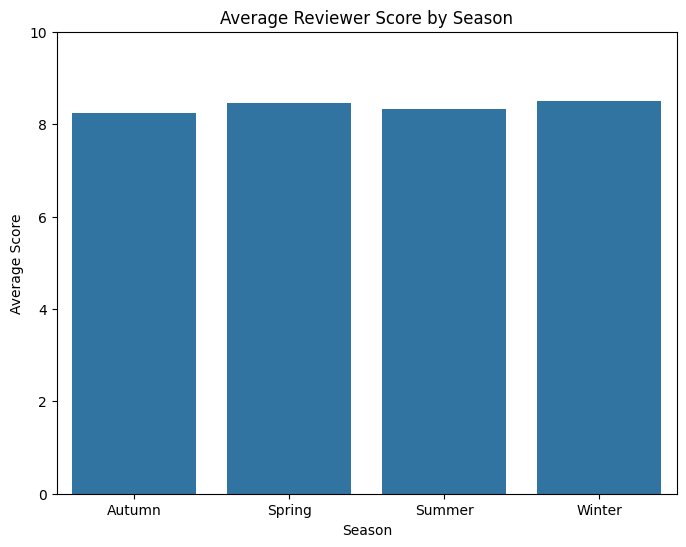

In [46]:
plt.figure(figsize=(8, 6))
sns.barplot(x=average_score_by_season.index, y=average_score_by_season.values)
plt.title('Average Reviewer Score by Season')
plt.xlabel('Season')
plt.ylabel('Average Score')
plt.ylim(0, 10) # Assuming the score is out of 10
plt.show()

In [47]:
# Select numeric columns
numeric_df = df.select_dtypes(include=np.number)

# Calculate median for each numeric variable
display(numeric_df.median())

,0
Additional_Number_of_Scoring,342.0
Average_Score,8.4
Review_Total_Negative_Word_Counts,9.0
Total_Number_of_Reviews,2147.0
Review_Total_Positive_Word_Counts,11.0
Total_Number_of_Reviews_Reviewer_Has_Given,3.0
Reviewer_Score,8.8


# Create satisfaction DataFrame for analysis

---



---



In [48]:
# Function to classify scores into satisfaction categories
def categorize_score(score):
    if score < 7.5:
        return 'Not satisfy'
    elif 7.5 <= score < 9:
        return 'Neuter'
    elif score >= 9:
        return 'Satisfy'

# Function to classify scores into satisfaction categories
df['Review_satisfaction'] = df['Reviewer_Score'].apply(categorize_score)

# Quick check on a few rows
display(df[['Reviewer_Score', 'Review_satisfaction']].head())

,Reviewer_Score,Review_satisfaction
0,9.6,Satisfy
1,8.8,Neuter
2,7.9,Neuter
3,10.0,Satisfy
4,9.6,Satisfy


In [49]:
# Display full columns and rows (no truncation)
pd.options.display.max_columns = None
pd.options.display.max_rows = None

# Filter to keep only 'Satisfy' and 'Not satisfy' reviews
df_satisfaction = df[df['Review_satisfaction'].isin(['Satisfy', 'Not satisfy'])]

# Check new DataFrame
display(df_satisfaction.head())
df_satisfaction.info()

,Additional_Number_of_Scoring,Review_Date,Average_Score,Hotel_Name,Reviewer_Nationality,Negative_Review,Review_Total_Negative_Word_Counts,Total_Number_of_Reviews,Positive_Review,Review_Total_Positive_Word_Counts,Total_Number_of_Reviews_Reviewer_Has_Given,Reviewer_Score,Country,City,Address,cleaned_tags,room_type,layout,room_count,capacity,features,pet_info,reservation_method,traveler_types,trip_types,stay_duration,Seasons,Review_satisfaction
0,904,2017-07-21,8.1,Hotel Da Vinci,United Kingdom,Would have appreciated a shop in the hotel th...,52,16670,Hotel was great clean friendly staff free bre...,62,1,9.6,Italy,Milan,Via Senigallia 6 20161,Double Room,Double Room,Standard,,,,No pets,Reserved from PC or tablet,Couple,Leisure trip,Stayed 2 nights,Summer,Satisfy
3,241,2015-10-17,9.1,Hotel Principe Di Savoia,United States of America,No Negative,0,1543,Everything including the nice upgrade The Hot...,27,9,10.0,Italy,Milan,Piazza Della Repubblica 17 Central Station 20124,Ambassador Junior Suite,Suite,Standard,,,,No pets,Reserved from PC or tablet,Couple,Leisure trip,Stayed 1 night,Autumn,Satisfy
4,834,2016-05-16,9.1,Hotel Esther a,United Kingdom,No Negative,0,4687,Lovely hotel v welcoming staff,7,2,9.6,Netherlands,Amsterdam,Singel 303 309 Amsterdam City Center 1012 WJ,Classic Double or Twin Room,Double Room,Standard,,,,No pets,Reserved from mobile device,Solo traveler,Business trip,Stayed 2 nights,Spring,Satisfy
8,211,2016-06-25,8.9,Hotel Saint Petersbourg Opera,Ireland,Pity about the two days of rain,8,2412,Its centrality proximity to our destination,7,1,9.2,France,Paris,35 Rue Caumartin 9th arr 75009,Double or Twin Room,Double Room,Standard,,,,No pets,Reserved from PC or tablet,Group,,Stayed 1 night,Summer,Satisfy
9,61,2015-09-30,7.4,St George Hotel,Canada,Didn t like it at all construction was in pro...,18,334,Didn t like anything about the stay if i had ...,25,1,2.5,United Kingdom,London,49 Gloucester Place Marble Arch Westminster Bo...,Standard Triple Room,Other,Standard,,,,No pets,Reserved from mobile device,Couple,,Stayed 2 nights,Autumn,Not satisfy


<class 'pandas.core.frame.DataFrame'>
Index: 13935 entries, 0 to 19999
Data columns (total 28 columns):
 #   Column                                      Non-Null Count  Dtype         
---  ------                                      --------------  -----         
 0   Additional_Number_of_Scoring                13935 non-null  int64         
 1   Review_Date                                 13935 non-null  datetime64[ns]
 2   Average_Score                               13935 non-null  float64       
 3   Hotel_Name                                  13935 non-null  object        
 4   Reviewer_Nationality                        13935 non-null  object        
 5   Negative_Review                             13935 non-null  object        
 6   Review_Total_Negative_Word_Counts           13935 non-null  int64         
 7   Total_Number_of_Reviews                     13935 non-null  int64         
 8   Positive_Review                             13935 non-null  object        
 9   Review_Tota

AXIS 1 – Does satisfaction vary by traveler type or destination?

Analysis plan

1. Satisfaction by traveler type (traveler_types)

2. Satisfaction by trip type (trip_types)

3. Satisfaction by destination (Hotel_Address or City)
→ Do some cities or countries generate lower scores?

4. Cross-check with nationality
→ Do travelers from certain nationalities rate more strictly?

5. Influence of room (room_type, room_count, features)
→ Do stays in suites or rooms with a view receive higher ratings?
→ Do rooms with a balcony/spa/terrace improve the experience?

6. Effect of pets (pet_info)
→ Do stays with pets generate more dissatisfaction?
→ Could indicate lack of adapted facilities

7. Stay duration (stay_duration)
→ Is there a correlation between long stays and lower satisfaction?
→ Or conversely: short stays = less demanding customers?

In [50]:
# 1. Satisfaction par type de voyageur (traveler_types)

# Je supprime les lignes où le traveler_types est vide ou bien rempli d'espaces et qui donne une moyenne de 8,594
df_satisfaction_voyageur = (df_satisfaction.dropna().query("traveler_types != ''"))

# Calcul des effectifs 'Satisfy' et 'Not satisfy' par type de voyageur
satisfaction_par_type_voy = df_satisfaction_voyageur.groupby(['traveler_types', 'Review_satisfaction']).size().unstack(fill_value=0)

# Calcul du total et des pourcentages
satisfaction_par_type_voy['Total'] = satisfaction_par_type_voy.sum(axis=1)
satisfaction_par_type_voy['% Satisfy'] = (satisfaction_par_type_voy['Satisfy'] / satisfaction_par_type_voy['Total']) * 100
satisfaction_par_type_voy['% Not Satisfy'] = 100 - satisfaction_par_type_voy['% Satisfy']

# Trier les pays par % de satisfaction croissante
satisfaction_par_type_voy = satisfaction_par_type_voy.sort_values(by='% Satisfy')

# Affichage du tableau
print(satisfaction_par_type_voy[['Satisfy', 'Not satisfy', '% Satisfy', '% Not Satisfy']].round(2))


# les types de voyageurs les plus satisfaits sont dans l'odre : les couples, les groupes puis les familles avec enfants

Review_satisfaction         Satisfy  Not satisfy  % Satisfy  % Not Satisfy
traveler_types                                                            
Solo traveler                  1727         1192      59.16          40.84
Family with young children     1060          542      66.17          33.83
Group                          1241          556      69.06          30.94
Family with older children      496          208      70.45          29.55
Couple                         4966         1894      72.39          27.61


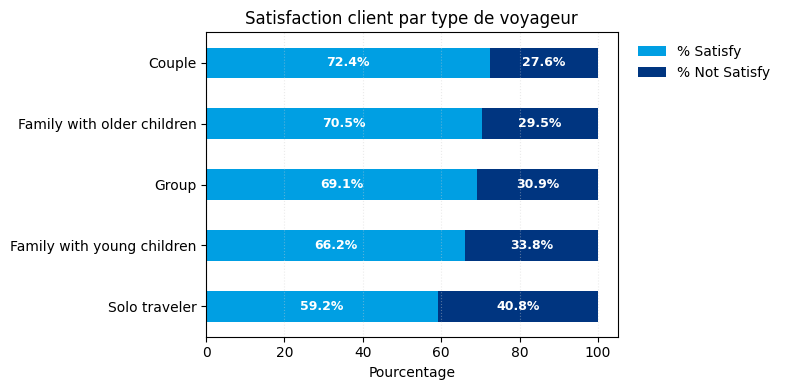

In [51]:
# More compact size
nb_type_voy = satisfaction_par_type_voy.shape[0]
hauteur = max(4, nb_type_voy * 0.4)
largeur = 8

fig, ax = plt.subplots(figsize=(largeur, hauteur))
satisfaction_par_type_voy[['% Satisfy', '% Not Satisfy']].plot(
    kind='barh',
    stacked=True,
    color=['#009FE3', '#003580'],  # Cerulean, Resolution Blue
    ax=ax
)

# Fully white background
ax.set_facecolor("white")
fig.patch.set_facecolor("white")

# White values inside bars
for p in ax.patches:
    w = p.get_width()
    if w > 0:
        ax.text(p.get_x() + w/2, p.get_y() + p.get_height()/2,
                f"{w:.1f}%", ha='center', va='center',
                color='white', fontsize=9, fontweight='bold')

ax.set_title("Satisfaction client par type de voyageur", fontsize=12)
ax.set_xlabel("Pourcentage", fontsize=10)
ax.set_ylabel(None)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
ax.grid(axis='x', linestyle=':', alpha=0.4, color="#CFCFCF")

plt.tight_layout()
plt.show()

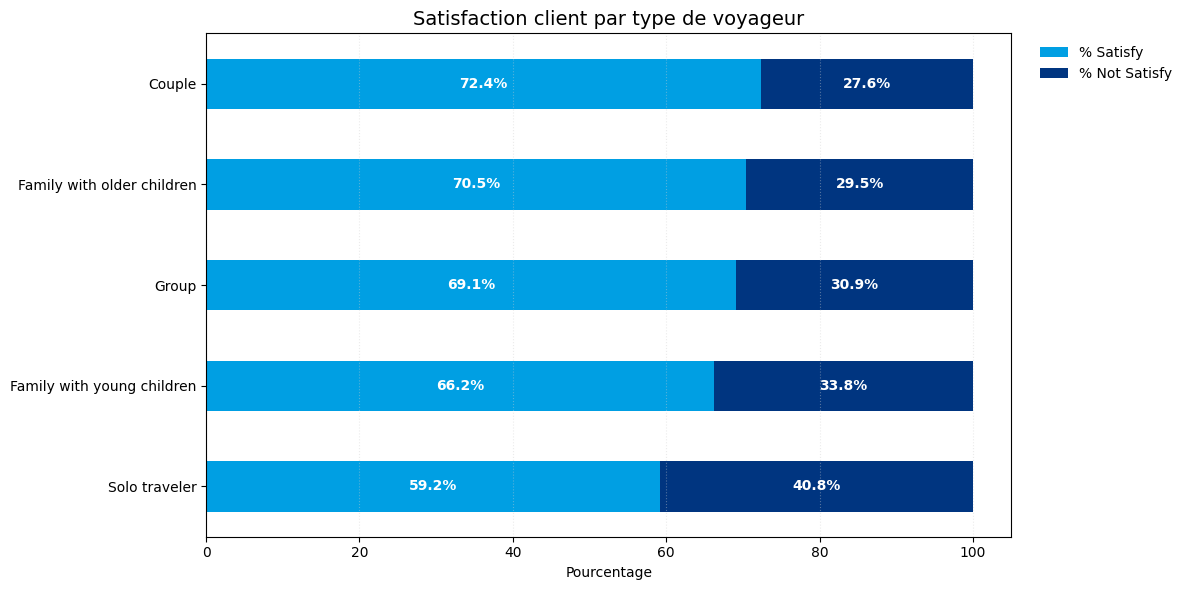

In [52]:
# Dynamic size
nb_type_voy = satisfaction_par_type_voy.shape[0]
hauteur = max(6, nb_type_voy * 0.8)

fig, ax = plt.subplots(figsize=(12, hauteur))
satisfaction_par_type_voy[['% Satisfy', '% Not Satisfy']].plot(
    kind='barh',
    stacked=True,
    color=['#009FE3', '#003580'],  # Cerulean, Resolution Blue
    ax=ax
)

# White values inside bars
for p in ax.patches:
    w = p.get_width()
    if w > 0:
        ax.text(p.get_x() + w/2, p.get_y() + p.get_height()/2,
                f"{w:.1f}%", ha='center', va='center',
                color='white', fontsize=10, fontweight='bold')

ax.set_title("Satisfaction client par type de voyageur", fontsize=14)
ax.set_xlabel("Pourcentage")
ax.set_ylabel(None)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
ax.grid(axis='x', linestyle=':', alpha=0.4, color="#CFCFCF")
plt.tight_layout()
plt.show()

In [53]:
# 2. Satisfaction by trip type (trip_types) _ Are leisure stays rated higher than business stays? _ MARION

# Satisfy/Not satisfy with calculation of the average scores given by trip type

# I want to know the number of empty trip_types rows and check they are not significant before deleting them

nb_vides = (df_satisfaction['trip_types'].str.strip() == "").sum()
print("Nombre de lignes vides :", nb_vides)

# I deleted the rows where trip_types is empty or filled with spaces using the code: df_satisfaction_voyageur = (df_satisfaction.dropna().query("trip_types != ''"))

# I calculate the average satisfaction score by trip type
moyennes = (df_satisfaction_voyageur.groupby('trip_types')['Reviewer_Score'].mean().sort_values()).round(2)
print("Les moyennes par type de voyage sont de :", moyennes)

# Count 'Satisfy' and 'Not satisfy' by trip type
satisfaction_par_type_voyage = df_satisfaction_voyageur.groupby(['trip_types', 'Review_satisfaction']).size().unstack(fill_value=0)

# Calculate totals and percentages
satisfaction_par_type_voyage['Total'] = satisfaction_par_type_voyage.sum(axis=1)
satisfaction_par_type_voyage['% Satisfy'] = (satisfaction_par_type_voyage['Satisfy'] / satisfaction_par_type_voyage['Total']) * 100
satisfaction_par_type_voyage['% Not Satisfy'] = 100 - satisfaction_par_type_voyage['% Satisfy']

# Sort trip types by increasing % of satisfaction
satisfaction_par_type_voyage = satisfaction_par_type_voyage.sort_values(by='% Satisfy')

# Display the table
print(satisfaction_par_type_voyage[['Satisfy', 'Not satisfy']].round(2))



Nombre de lignes vides : 398
Les moyennes par type de voyage sont de : trip_types
Business trip    7.83
                 8.11
Leisure trip     8.61
Name: Reviewer_Score, dtype: float64
Review_satisfaction  Satisfy  Not satisfy
trip_types                               
Business trip           1203         1023
                         236          162
Leisure trip            8051         3207


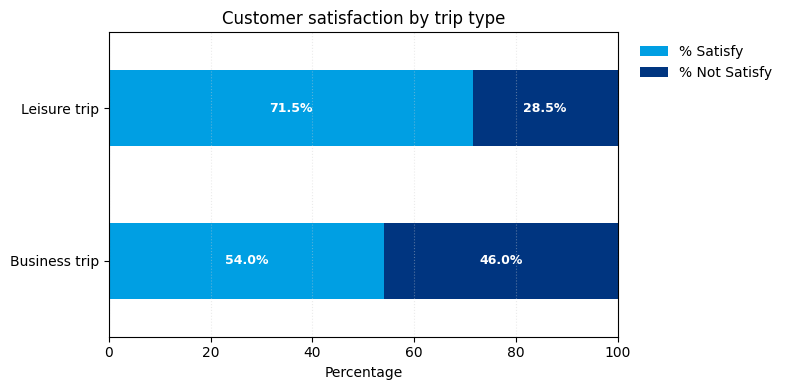

In [54]:
# Copy useful columns
df_plot = satisfaction_par_type_voyage[['% Satisfy', '% Not Satisfy']].copy()

# Cleaning: remove empty rows, NaN, or 100% null
df_plot = df_plot[df_plot.index.notna()]
df_plot = df_plot[df_plot.index.astype(str).str.strip() != ""]
df_plot = df_plot[(df_plot != 0).any(axis=1)]

# More compact size
nb = df_plot.shape[0]
hauteur = max(4, nb * 0.4)   # reduce height
largeur = 8                  # reduced width

fig, ax = plt.subplots(figsize=(largeur, hauteur))
df_plot.plot(
    kind='barh',
    stacked=True,
    color=['#009FE3', '#003580'],  # Cerulean, Resolution Blue
    ax=ax
)

# Fully white background
ax.set_facecolor("white")
fig.patch.set_facecolor("white")

# White values inside bars
for p in ax.patches:
    w = p.get_width()
    if w > 0:
        ax.text(
            p.get_x() + w/2, p.get_y() + p.get_height()/2,
            f"{w:.1f}%", ha='center', va='center',
            color='white', fontsize=9, fontweight='bold'
        )

# Update labels in English
ax.set_title("Customer satisfaction by trip type", fontsize=12)
ax.set_xlabel("Percentage", fontsize=10)
ax.set_ylabel(None)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
ax.grid(axis='x', linestyle=':', alpha=0.4, color="#CFCFCF")
ax.set_xlim(0, 100)

plt.tight_layout()
plt.show()



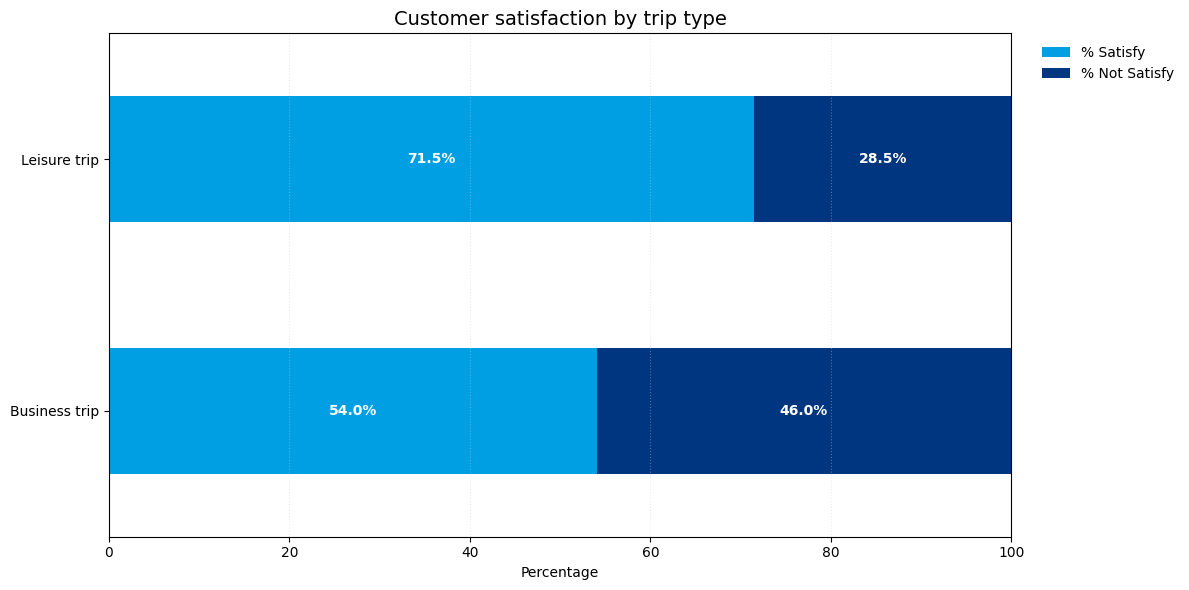

In [55]:
# Copy useful columns
df_plot = satisfaction_par_type_voyage[['% Satisfy', '% Not Satisfy']].copy()

# Cleaning: remove empty rows, NaN, or 100% null
df_plot = df_plot[df_plot.index.notna()]
df_plot = df_plot[df_plot.index.astype(str).str.strip() != ""]
df_plot = df_plot[(df_plot != 0).any(axis=1)]

# Dynamic size after cleaning
nb = df_plot.shape[0]
hauteur = max(6, nb * 0.8)

fig, ax = plt.subplots(figsize=(12, hauteur))
df_plot.plot(
    kind='barh',
    stacked=True,
    color=['#009FE3', '#003580'],  # Cerulean, Resolution Blue
    ax=ax
)

# White values inside bars
for p in ax.patches:
    w = p.get_width()
    if w > 0:
        ax.text(
            p.get_x() + w/2, p.get_y() + p.get_height()/2,
            f"{w:.1f}%", ha='center', va='center',
            color='white', fontsize=10, fontweight='bold'
        )

# Update labels in English
ax.set_title("Customer satisfaction by trip type", fontsize=14)
ax.set_xlabel("Percentage")
ax.set_ylabel(None)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
ax.grid(axis='x', linestyle=':', alpha=0.4, color="#CFCFCF")
ax.set_xlim(0, 100)

plt.tight_layout()
plt.show()




In [56]:
# 3. Satisfaction by destination (Country)
# Do some countries generate lower scores?

# Count 'Satisfy' and 'Not satisfy' by country
satisfaction_par_pays = df_satisfaction.groupby(['Country', 'Review_satisfaction']).size().unstack(fill_value=0)

# Calculate totals and percentages
satisfaction_par_pays['Total'] = satisfaction_par_pays.sum(axis=1)
satisfaction_par_pays['% Satisfy'] = (satisfaction_par_pays['Satisfy'] / satisfaction_par_pays['Total']) * 100
satisfaction_par_pays['% Not Satisfy'] = 100 - satisfaction_par_pays['% Satisfy']

# Sort countries by increasing % of satisfaction
satisfaction_par_pays = satisfaction_par_pays.sort_values(by='% Satisfy')

# Display the table
print(satisfaction_par_pays[['Satisfy', 'Not satisfy', '% Satisfy', '% Not Satisfy']].round(2))



Review_satisfaction  Satisfy  Not satisfy  % Satisfy  % Not Satisfy
Country                                                            
United Kingdom          4656         2436      65.65          34.35
Italy                    712          350      67.04          32.96
France                  1120          547      67.19          32.81
Netherlands             1081          412      72.40          27.60
Spain                   1192          408      74.50          25.50
Austria                  768          253      75.22          24.78


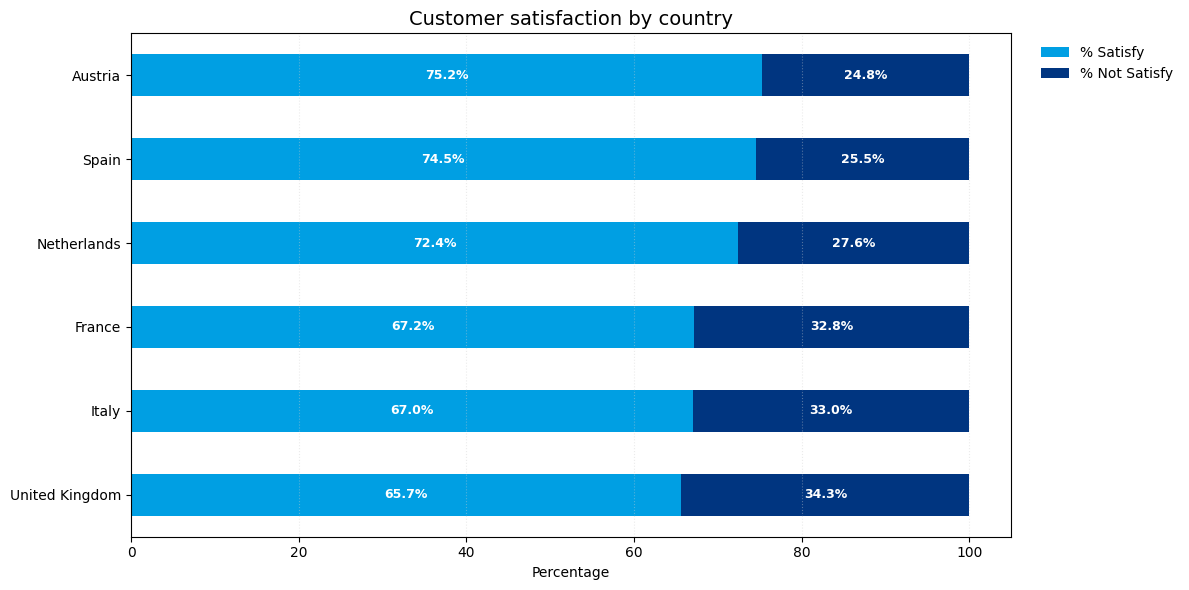

In [57]:
# Dynamic size
nb_pays = satisfaction_par_pays.shape[0]
hauteur = max(6, nb_pays * 0.6)

fig, ax = plt.subplots(figsize=(12, hauteur))
satisfaction_par_pays[['% Satisfy', '% Not Satisfy']].plot(
    kind='barh',
    stacked=True,
    color=['#009FE3', '#003580'],  # Cerulean (Satisfy), Resolution Blue (Not Satisfy)
    ax=ax
)

# White values inside bars
for p in ax.patches:
    w = p.get_width()
    if w > 0:
        ax.text(p.get_x() + w/2, p.get_y() + p.get_height()/2,
                f"{w:.1f}%", ha='center', va='center',
                color='white', fontsize=9, fontweight='bold')

# Update labels in English
ax.set_title("Customer satisfaction by country", fontsize=14)
ax.set_xlabel("Percentage")
ax.set_ylabel(None)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
ax.grid(axis='x', linestyle=':', alpha=0.4, color="#CFCFCF")
plt.tight_layout()
plt.show()


In [58]:
# 4. Cross-check with nationality
# 4.1 Do some nationalities rate more strictly than others?

# Group by nationality and satisfaction
satisfaction_par_nationalite = df_satisfaction.groupby(['Reviewer_Nationality', 'Review_satisfaction']).size().unstack(fill_value=0)

# Totals and percentages
satisfaction_par_nationalite['Total'] = satisfaction_par_nationalite.sum(axis=1)
satisfaction_par_nationalite['% Satisfy'] = (satisfaction_par_nationalite['Satisfy'] / satisfaction_par_nationalite['Total']) * 100
satisfaction_par_nationalite['% Not Satisfy'] = 100 - satisfaction_par_nationalite['% Satisfy']

# Filter to keep only nationalities with at least 50 reviews
satisfaction_filtrée = satisfaction_par_nationalite[satisfaction_par_nationalite['Total'] >= 50]

# Top 5 most satisfied nationalities
top_5_satisfaits = satisfaction_filtrée.sort_values(by='% Satisfy', ascending=False).head(5)

# Top 5 strictest nationalities
top_5_strictes = satisfaction_filtrée.sort_values(by='% Satisfy').head(5)



In [59]:
top_5_satisfaits

Review_satisfaction,Not satisfy,Satisfy,Total,% Satisfy,% Not Satisfy
Reviewer_Nationality,,,,,
New Zealand,17,76,93,81.720430,18.279570
United States of America,211,798,1009,79.088206,20.911794
Israel,42,157,199,78.894472,21.105528
Australia,125,450,575,78.260870,21.739130
Hungary,14,49,63,77.777778,22.222222


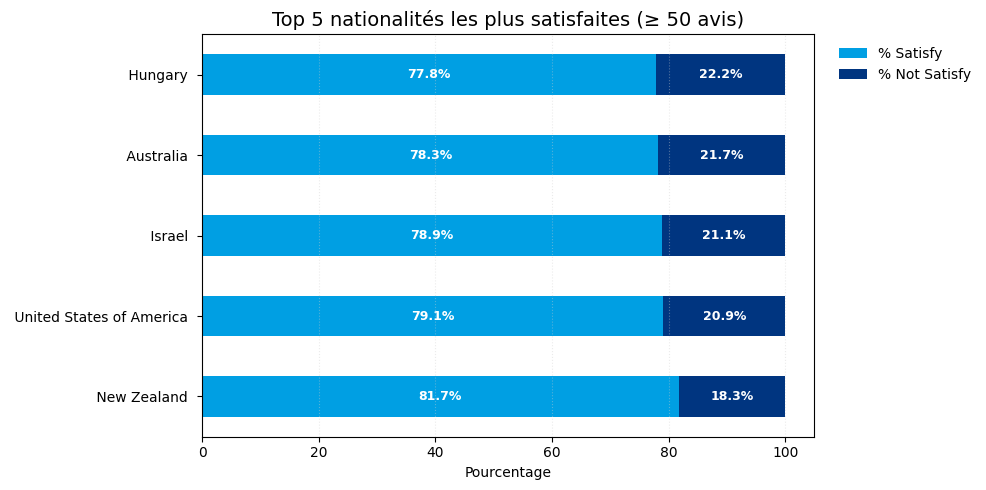

In [60]:
# TOP 5 most satisfied
fig, ax = plt.subplots(figsize=(10, 5))
top_5_satisfaits[['% Satisfy', '% Not Satisfy']].plot(
    kind='barh',
    stacked=True,
    color=['#009FE3', '#003580'],  # Cerulean (Satisfy), Resolution Blue (Not Satisfy)
    ax=ax
)

# White values inside bars
for p in ax.patches:
    w = p.get_width()
    if w > 0:
        ax.text(p.get_x() + w/2, p.get_y() + p.get_height()/2,
                f"{w:.1f}%", ha='center', va='center',
                color='white', fontsize=9, fontweight='bold')

# Formatting
ax.set_title("Top 5 nationalités les plus satisfaites (≥ 50 avis)", fontsize=14)
ax.set_xlabel("Pourcentage")
ax.set_ylabel(None)  # Remove "Nationality"
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
ax.grid(axis='x', linestyle=':', alpha=0.4, color="#CFCFCF")

plt.tight_layout()
plt.show()

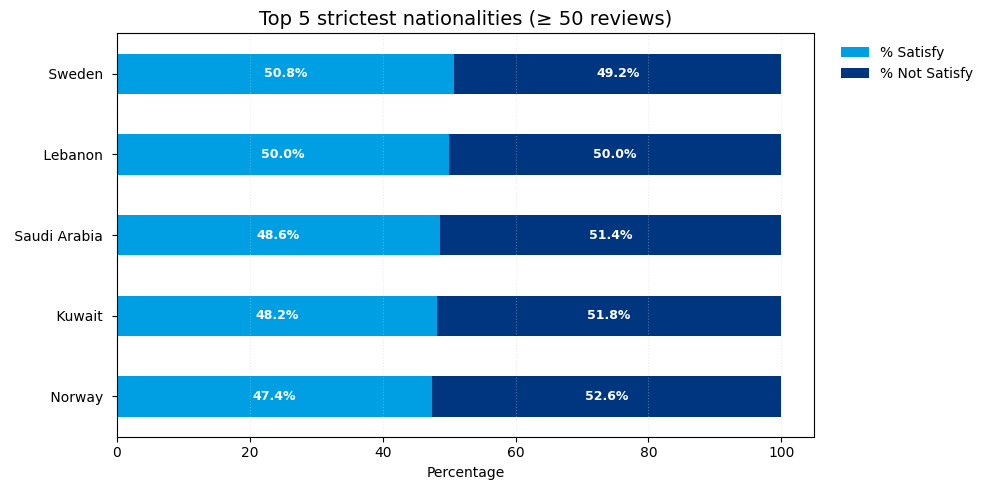

In [61]:
# TOP 5 strictest
fig, ax = plt.subplots(figsize=(10, 5))
top_5_strictes[['% Satisfy', '% Not Satisfy']].plot(
    kind='barh',
    stacked=True,
    color=['#009FE3', '#003580'],  # Cerulean (Satisfy), Resolution Blue (Not Satisfy)
    ax=ax
)

# White values inside bars
for p in ax.patches:
    w = p.get_width()
    if w > 0:
        ax.text(p.get_x() + w/2, p.get_y() + p.get_height()/2,
                f"{w:.1f}%", ha='center', va='center',
                color='white', fontsize=9, fontweight='bold')

# Formatting
ax.set_title("Top 5 strictest nationalities (≥ 50 reviews)", fontsize=14)
ax.set_xlabel("Percentage")
ax.set_ylabel(None)  # Remove "Nationality"
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
ax.grid(axis='x', linestyle=':', alpha=0.4, color="#CFCFCF")

plt.tight_layout()
plt.show()

In [62]:
# 4.2. Cross-check with nationality
# Where do these nationalities travel the most? (destination Country)

# Step 1 – Satisfaction by nationality
satisfaction_par_nationalite = df.groupby(['Reviewer_Nationality', 'Review_satisfaction']).size().unstack(fill_value=0)

satisfaction_par_nationalite['Total'] = satisfaction_par_nationalite.sum(axis=1)
satisfaction_par_nationalite['% Satisfy'] = (satisfaction_par_nationalite['Satisfy'] / satisfaction_par_nationalite['Total']) * 100
satisfaction_filtrée = satisfaction_par_nationalite[satisfaction_par_nationalite['Total'] >= 50]

# Step 2 – Top 5 most satisfied and most strict
top_5_satisfaits = satisfaction_filtrée.sort_values(by='% Satisfy', ascending=False).head(5)
top_5_strictes = satisfaction_filtrée.sort_values(by='% Satisfy').head(5)

# Step 3 – Most visited countries by these two groups

# a) For the satisfied
df_satisfaits = df[df['Reviewer_Nationality'].isin(top_5_satisfaits.index)]
visites_satisfaits = df_satisfaits.groupby(['Reviewer_Nationality', 'Country']).size().reset_index(name='Nombre_avis')
pays_satisfaits = visites_satisfaits.sort_values('Nombre_avis', ascending=False).drop_duplicates('Reviewer_Nationality')
pays_satisfaits['Groupe'] = 'Top satisfied'

# b) For the strict
df_strictes = df[df['Reviewer_Nationality'].isin(top_5_strictes.index)]
visites_strictes = df_strictes.groupby(['Reviewer_Nationality', 'Country']).size().reset_index(name='Nombre_avis')
pays_strictes = visites_strictes.sort_values('Nombre_avis', ascending=False).drop_duplicates('Reviewer_Nationality')
pays_strictes['Groupe'] = 'Top strict'

# Step 4 – Merge and display
pays_comparatif = pd.concat([pays_satisfaits, pays_strictes])
pays_comparatif = pays_comparatif[['Groupe', 'Reviewer_Nationality', 'Country', 'Nombre_avis']]

# Final display
print("\n Most visited countries by the 5 most satisfied and 5 strictest nationalities:\n")
print(pays_comparatif.sort_values(by='Groupe').to_string(index=False))


 Most visited countries by the 5 most satisfied and 5 strictest nationalities:

       Groupe       Reviewer_Nationality        Country  Nombre_avis
Top satisfied  United States of America  United Kingdom          414
Top satisfied                    Israel  United Kingdom           78
Top satisfied               New Zealand  United Kingdom           53
Top satisfied                     China  United Kingdom           48
Top satisfied                   Hungary         Austria           33
   Top strict                    Sweden  United Kingdom           56
   Top strict                   Lebanon          France           40
   Top strict                    Norway  United Kingdom           36
   Top strict                  Pakistan  United Kingdom           19
   Top strict                Luxembourg  United Kingdom           18


In [63]:
# Focus on missing/null variables

# WARNING: NULL VALUES REPRESENT A LARGE PROPORTION OF THE TOTAL:
# unknown room count represents 98% of the total,
# missing features represent 94% of the total

# I can check the number of rows and verify they are not significant before deleting them:
# nb_vides = (df_satisfaction['features'].str.strip() == "").sum() print("Number of empty rows:", nb_vides)

# I replace rows where the variable is empty or filled with spaces by "Unknown"
cols_cat = ['room_count', 'features', 'pet_info', 'stay_duration']

for col in cols_cat:
    df_satisfaction_voyageur[col] = (
        df_satisfaction_voyageur[col]
        .replace(r'^\s*$', 'Unknown', regex=True)
        .fillna('Unknown')
    )

Average scores by room type: room_type
Single Room    7.86
Apartment      8.10
Twin Room      8.22
Other          8.47
Double Room    8.47
Family         8.55
King Room      8.67
Queen Room     8.68
Suite          8.84
Name: Reviewer_Score, dtype: float64
Average scores by number of rooms: room_count
3           8.19
2           8.27
Unknown     8.47
4          10.00
Name: Reviewer_Score, dtype: float64
Average scores by room features: features
View, Terrace       7.72
Balcony             7.99
Unknown             8.45
Spa                 8.67
Lounge              8.86
View                8.86
Terrace             8.93
Balcony, View       9.05
Spa, View           9.20
Balcony, Lounge     9.60
Balcony, Spa        9.60
Spa, Terrace       10.00
Name: Reviewer_Score, dtype: float64
Review_satisfaction  Satisfy  Not satisfy  % Satisfy  % Not Satisfy
room_type                                                          
Single Room              339          287      54.15          45.85
Apartment 

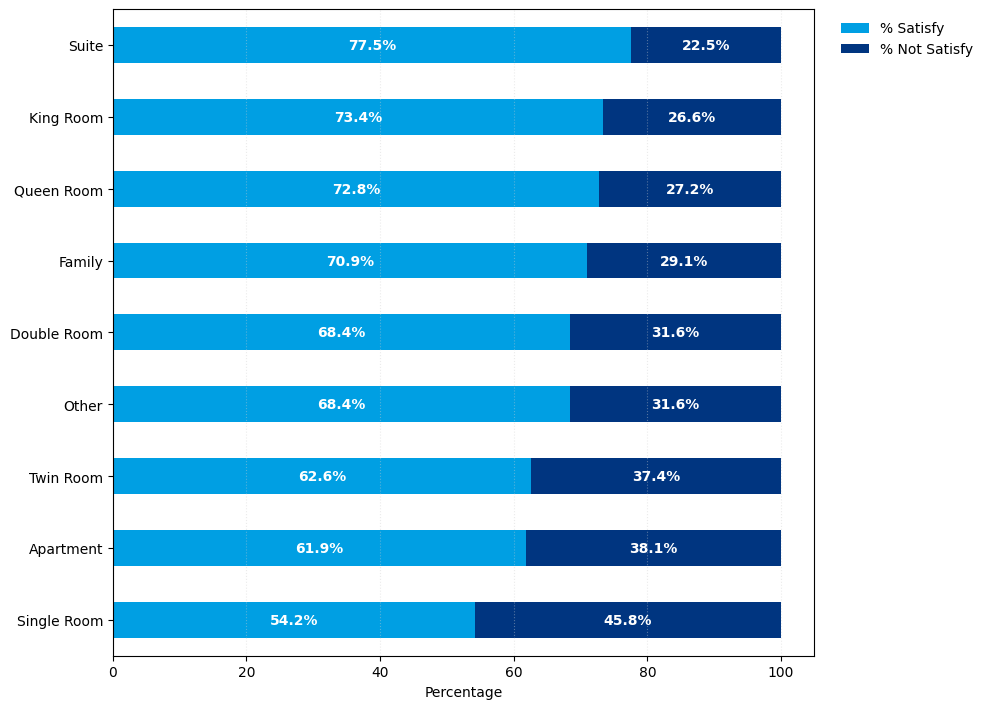

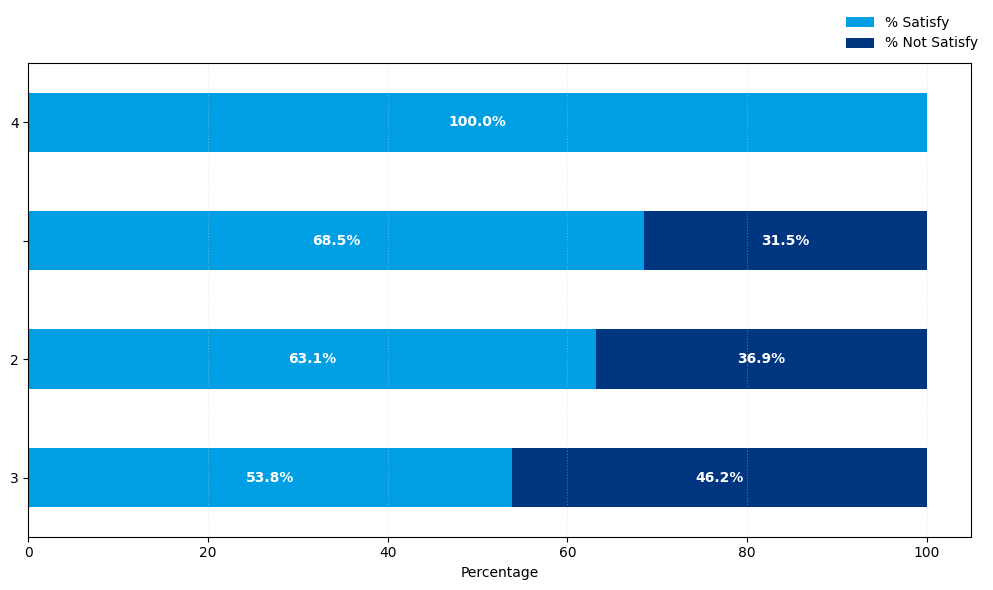

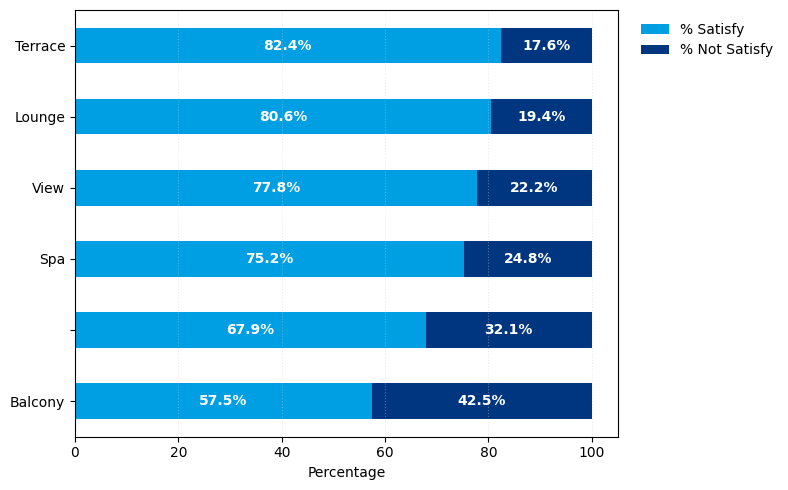

In [64]:
# 5. Influence of the room (room_type, room_count, features)
# Do stays in suites or rooms with a view receive better ratings?
# Do rooms with a balcony / spa / terrace improve the experience?

# Method 1 – Satisfy/Not satisfy with calculation of the average scores by travel type

# AVERAGES
# Calculate average satisfaction score by room type
moyennes_type_chambre = (df_satisfaction_voyageur.groupby('room_type')['Reviewer_Score'].mean().sort_values()).round(2)
print("Average scores by room type:", moyennes_type_chambre)

# Calculate average satisfaction score by room size (number of rooms)
moyennes_nb_chambre = (df_satisfaction_voyageur.groupby('room_count')['Reviewer_Score'].mean().sort_values()).round(2)
print("Average scores by number of rooms:", moyennes_nb_chambre)

# Calculate average satisfaction score by room features
moyennes_feat_chambre = (df_satisfaction_voyageur.groupby('features')['Reviewer_Score'].mean().sort_values()).round(2)
print("Average scores by room features:", moyennes_feat_chambre)


# EFFECTIVES SATISFY/NOT SATISFY
# Count 'Satisfy' and 'Not satisfy' by room type
satisfaction_par_type_chambre = df_satisfaction.groupby(['room_type', 'Review_satisfaction']).size().unstack(fill_value=0)

# Count 'Satisfy' and 'Not satisfy' by room size
satisfaction_par_nb_chambre = df_satisfaction.groupby(['room_count', 'Review_satisfaction']).size().unstack(fill_value=0)

# Count 'Satisfy' and 'Not satisfy' by room features
satisfaction_equipement_chambre = df_satisfaction.groupby(['features', 'Review_satisfaction']).size().unstack(fill_value=0)


# TOTAL AND PERCENTAGES
# Calculate totals and percentages for room_type
satisfaction_par_type_chambre['Total'] = satisfaction_par_type_chambre.sum(axis=1)
satisfaction_par_type_chambre['% Satisfy'] = (satisfaction_par_type_chambre['Satisfy'] / satisfaction_par_type_chambre['Total']) * 100
satisfaction_par_type_chambre['% Not Satisfy'] = 100 - satisfaction_par_type_chambre['% Satisfy']

# Calculate totals and percentages for room_count
satisfaction_par_nb_chambre['Total'] = satisfaction_par_nb_chambre.sum(axis=1)
satisfaction_par_nb_chambre['% Satisfy'] = (satisfaction_par_nb_chambre['Satisfy'] / satisfaction_par_nb_chambre['Total']) * 100
satisfaction_par_nb_chambre['% Not Satisfy'] = 100 - satisfaction_par_nb_chambre['% Satisfy']

# Calculate totals and percentages for features
satisfaction_equipement_chambre['Total'] = satisfaction_equipement_chambre.sum(axis=1)
satisfaction_equipement_chambre['% Satisfy'] = (satisfaction_equipement_chambre['Satisfy'] / satisfaction_equipement_chambre['Total']) * 100
satisfaction_equipement_chambre['% Not Satisfy'] = 100 - satisfaction_equipement_chambre['% Satisfy']


# Filter to keep features with at least 50 reviews
satisfaction_equipement_filtrée = satisfaction_equipement_chambre[satisfaction_equipement_chambre['Total'] >= 50]

# Sort by increasing % satisfaction
satisfaction_par_type_chambre = satisfaction_par_type_chambre.sort_values(by='% Satisfy')
satisfaction_par_nb_chambre = satisfaction_par_nb_chambre.sort_values(by='% Satisfy')
satisfaction_equipement_chambre = satisfaction_equipement_filtrée.sort_values(by='% Satisfy')


# Display tables
print(satisfaction_par_type_chambre[['Satisfy', 'Not satisfy', '% Satisfy', '% Not Satisfy']].round(2))
print(satisfaction_par_nb_chambre[['Satisfy', 'Not satisfy', '% Satisfy', '% Not Satisfy']].round(2))
print(satisfaction_equipement_chambre[['Satisfy', 'Not satisfy', '% Satisfy', '% Not Satisfy']].round(2))


# Dynamic chart size by room type
nb_type_chambre = satisfaction_par_type_chambre.shape[0]
hauteur = max(5, nb_type_voy * 0.6)

# Dynamic chart size by room count
nb_chambre = satisfaction_par_nb_chambre.shape[0]
hauteur = max(5, nb_type_voy * 0.6)

# Dynamic chart size by room features
equpement = satisfaction_equipement_chambre.shape[0]
hauteur = max(5, nb_type_voy * 0.6)


# Stacked horizontal chart by room type
nb_type_chambre = satisfaction_par_type_chambre.shape[0]
hauteur = max(6, nb_type_chambre * 0.8)

fig, ax = plt.subplots(figsize=(12, hauteur))

satisfaction_par_type_chambre[['% Satisfy', '% Not Satisfy']].plot(
    kind='barh',
    stacked=True,
    figsize=(10, hauteur),
    color=['#009FE3', '#003580'],
    ax=ax
)

# White values inside bars
for p in ax.patches:
    w = p.get_width()
    if w > 0:
        ax.text(p.get_x() + w/2, p.get_y() + p.get_height()/2,
                f"{w:.1f}%", ha='center', va='center',
                color='white', fontsize=10, fontweight='bold')


ax.set_title(None)
ax.set_xlabel("Percentage")
ax.set_ylabel(None)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
ax.grid(axis='x', linestyle=':', alpha=0.4, color="#CFCFCF")
plt.tight_layout()
plt.show()


# Stacked horizontal chart by room count
nb_chambre = satisfaction_par_nb_chambre.shape[0]
hauteur = max(6, nb_chambre * 0.8)

fig, ax = plt.subplots(figsize=(12, hauteur))

satisfaction_par_nb_chambre[['% Satisfy', '% Not Satisfy']].plot(
    kind='barh',
    stacked=True,
    figsize=(10, hauteur),
    color=['#009FE3', '#003580'],
    ax=ax
)

# White values inside bars
for p in ax.patches:
    w = p.get_width()
    if w > 0:
        ax.text(p.get_x() + w/2, p.get_y() + p.get_height()/2,
                f"{w:.1f}%", ha='center', va='center',
                color='white', fontsize=10, fontweight='bold')

ax.set_title(None)
ax.set_xlabel("Percentage")
ax.set_ylabel(None)
ax.legend(bbox_to_anchor=(1.02,1), loc='lower right', frameon=False)
ax.grid(axis='x', linestyle=':', alpha=0.4, color="#CFCFCF")
plt.tight_layout()
plt.show()


# Stacked horizontal chart by room features

equipement_chambre = satisfaction_equipement_chambre.shape[0]
hauteur = max(5, equipement_chambre * 0.8)

fig, ax = plt.subplots(figsize=(8, hauteur))


satisfaction_equipement_chambre[['% Satisfy', '% Not Satisfy']].plot(
    kind='barh',
    stacked=True,
    figsize=(8, hauteur),
    color=['#009FE3', '#003580'],
    ax=ax
)

# White values inside bars
for p in ax.patches:
    w = p.get_width()
    if w > 0:
        ax.text(p.get_x() + w/2, p.get_y() + p.get_height()/2,
                f"{w:.1f}%", ha='center', va='center',
                color='white', fontsize=10, fontweight='bold')

ax.set_title(None)
ax.set_xlabel("Percentage")
ax.set_ylabel(None)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
ax.grid(axis='x', linestyle=':', alpha=0.4, color="#CFCFCF")
plt.tight_layout()
plt.show()

In [65]:
satisfaction_equipement_chambre['Total'] = satisfaction_equipement_chambre.sum(axis=1)
somme = satisfaction_equipement_chambre.sum()
print(satisfaction_equipement_chambre)

print("The overall total is", somme)

Review_satisfaction  Not satisfy  Satisfy    Total  % Satisfy  % Not Satisfy
features                                                                    
Balcony                       34       46    260.0  57.500000      42.500000
                            4202     8885  26274.0  67.891801      32.108199
Spa                           25       76    302.0  75.247525      24.752475
View                         114      400   1128.0  77.821012      22.178988
Lounge                        13       54    234.0  80.597015      19.402985
Terrace                        9       42    202.0  82.352941      17.647059
The overall total is Review_satisfaction
Not satisfy       4397.000000
Satisfy           9503.000000
Total            28400.000000
% Satisfy          441.410294
% Not Satisfy      158.589706
dtype: float64


Number of empty rows: 0
Average scores by travelers' pet preference: pet_info
With a pet    8.27
No pets       8.47
Name: Reviewer_Score, dtype: float64
Review_satisfaction  Satisfy  Not satisfy  % Satisfy  % Not Satisfy
pet_info                                                           
With a pet                21           12      63.64          36.36
No pets                 9508         4394      68.39          31.61


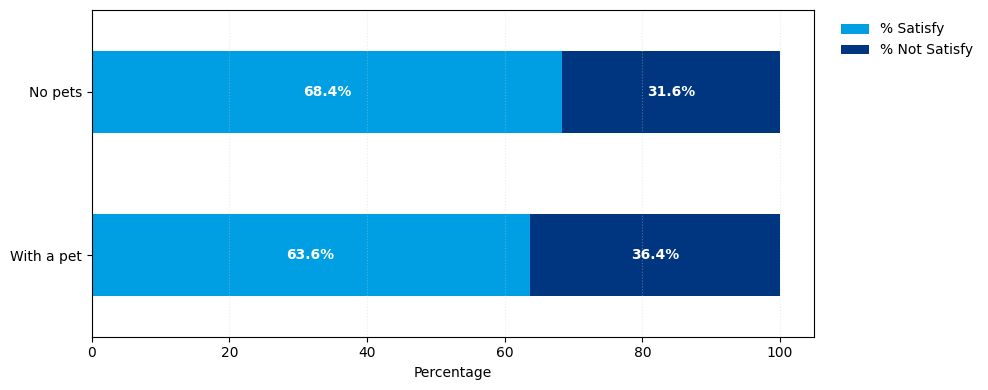

In [66]:
# 6. Effect of pets (pet_info)
# Do stays with pets generate more dissatisfaction?
# Could indicate a lack of adapted facilities

# Method: Satisfy/Not satisfy with calculation of the average scores by pet preference

# I want to know the number of empty pet_info rows and check they are not significant before deleting them
nb_vides = (df_satisfaction['pet_info'].str.strip() == "").sum()
print("Number of empty rows:", nb_vides)

# I could delete the rows where pet_info is empty or filled with spaces using:
# df_satisfaction_voyageur = (df_satisfaction.dropna().query("trip_types != ''"))

# Calculate average satisfaction score by pet preference
moyennes = (df_satisfaction_voyageur.groupby('pet_info')['Reviewer_Score'].mean().sort_values()).round(2)
print("Average scores by travelers' pet preference:", moyennes)

# Count 'Satisfy' and 'Not satisfy' by pet preference
satisfaction_pet_info = df_satisfaction.groupby(['pet_info', 'Review_satisfaction']).size().unstack(fill_value=0)

# Calculate totals and percentages
satisfaction_pet_info['Total'] = satisfaction_pet_info.sum(axis=1)
satisfaction_pet_info['% Satisfy'] = (satisfaction_pet_info['Satisfy'] / satisfaction_pet_info['Total']) * 100
satisfaction_pet_info['% Not Satisfy'] = 100 - satisfaction_pet_info['% Satisfy']

# Sort customers by increasing % satisfaction
satisfaction_pet_info = satisfaction_pet_info.sort_values(by='% Satisfy')

# Display the table
print(satisfaction_pet_info[['Satisfy', 'Not satisfy', '% Satisfy', '% Not Satisfy']].round(2))

# Dynamic chart size based on pet_info
nb_pet_info = satisfaction_pet_info.shape[0]
hauteur = max(5, nb_type_voy * 0.6)

# Stacked horizontal chart by pet preference
pref_pet = satisfaction_pet_info.shape[0]
hauteur = max(4, pref_pet * 0.8)

fig, ax = plt.subplots(figsize=(8, hauteur))

satisfaction_pet_info[['% Satisfy', '% Not Satisfy']].plot(
    kind='barh',
    stacked=True,
    figsize=(10, hauteur),
    color=['#009FE3', '#003580'],
    ax=ax
)

# White values inside bars
for p in ax.patches:
    w = p.get_width()
    if w > 0:
        ax.text(p.get_x() + w/2, p.get_y() + p.get_height()/2,
                f"{w:.1f}%", ha='center', va='center',
                color='white', fontsize=10, fontweight='bold')


ax.set_title(None)
ax.set_xlabel("Percentage")
ax.set_ylabel(None)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
ax.grid(axis='x', linestyle=':', alpha=0.4, color="#CFCFCF")
plt.tight_layout()
plt.show()

Number of empty rows: 6
Review_satisfaction  Satisfy  Not satisfy  % Satisfy  % Not Satisfy
stay_duration                                                      
Stayed 21 nights           0            2       0.00         100.00
Stayed 17 nights           0            1       0.00         100.00
                           1            5      16.67          83.33
Stayed 14 nights           2            3      40.00          60.00
Stayed 18 nights           1            1      50.00          50.00
Stayed 11 nights           7            6      53.85          46.15
Stayed 10 nights          14           12      53.85          46.15
Stayed 9 nights           20           13      60.61          39.39
Stayed 7 nights          119           70      62.96          37.04
Stayed 8 nights           46           24      65.71          34.29
Stayed 13 nights           8            4      66.67          33.33
Stayed 5 nights          370          184      66.79          33.21
Stayed 2 nights         

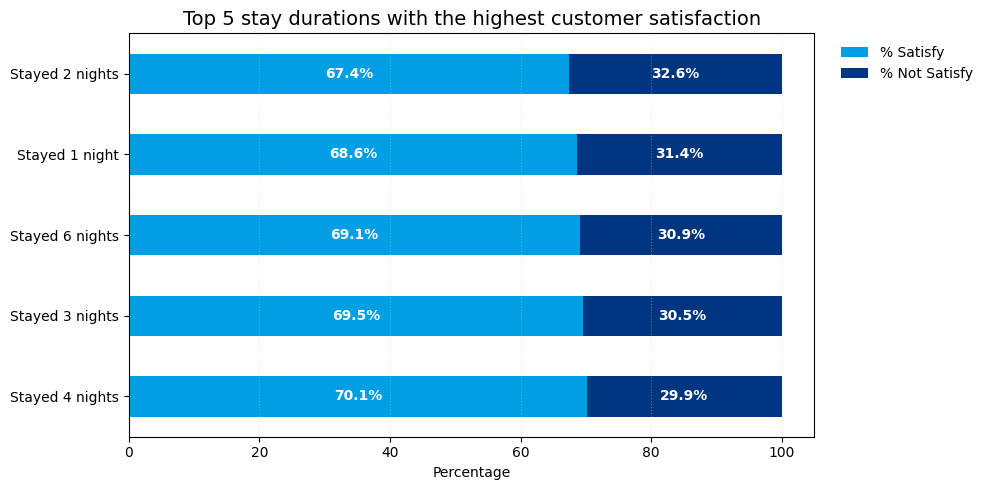

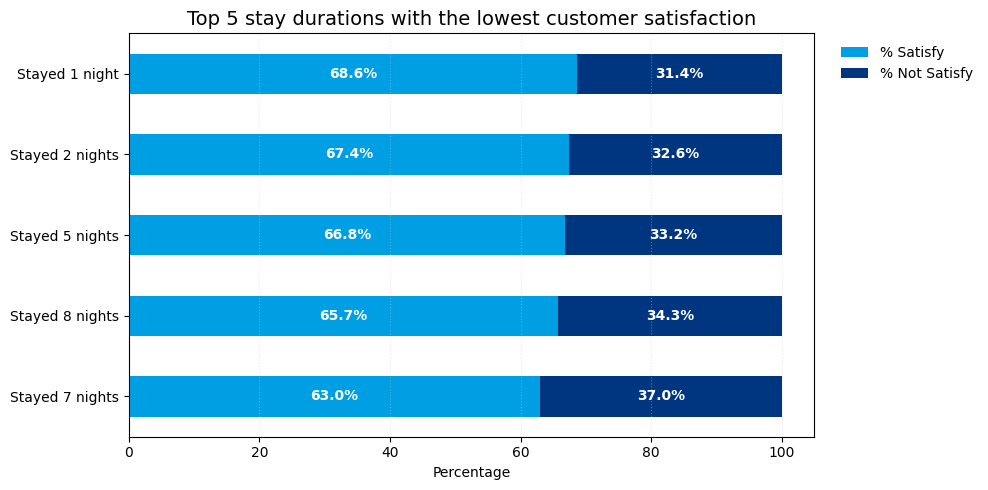

In [67]:
# 7. Stay duration (stay_duration)

# I want to know the number of empty stay_duration rows and check they are not significant before possibly deleting them
nb_vides = (df_satisfaction['stay_duration'].str.strip() == "").sum()
print("Number of empty rows:", nb_vides)

# I can delete the rows where "stay_duration" is empty or filled with spaces using:
# df_satisfaction_voyageur = (df_satisfaction.dropna().query("stay_duration != ''"))

# Count 'Satisfy' and 'Not satisfy' by stay duration
satisfaction_stay_duration = df_satisfaction.groupby(['stay_duration', 'Review_satisfaction']).size().unstack(fill_value=0)

# Calculate totals and percentages
satisfaction_stay_duration['Total'] = satisfaction_stay_duration.sum(axis=1)
satisfaction_stay_duration['% Satisfy'] = (satisfaction_stay_duration['Satisfy'] / satisfaction_stay_duration['Total']) * 100
satisfaction_stay_duration['% Not Satisfy'] = 100 - satisfaction_stay_duration['% Satisfy']

# Filter to keep stay durations with at least 50 reviews
satisfaction_filtrée = satisfaction_stay_duration[satisfaction_stay_duration['Total'] >= 50]

# Top 5 stay durations with the highest and lowest traveler satisfaction
top_5_sejour_strictes  = satisfaction_filtrée.sort_values(by='% Satisfy').head(5)
top_5_sejour_satisfaits = satisfaction_filtrée.sort_values(by='% Satisfy', ascending=False).head(5)

# Sort customers by increasing % satisfaction
satisfaction_stay_duration = satisfaction_stay_duration.sort_values(by='% Satisfy', ascending=True)

# Display the table
print(satisfaction_stay_duration[['Satisfy', 'Not satisfy', '% Satisfy', '% Not Satisfy']].round(2))


# Stacked horizontal chart of satisfaction by stay duration
duree_sejour = satisfaction_stay_duration.shape[0]
hauteur = max(6, duree_sejour * 0.8)

# TOP 5 stay durations with the highest customer satisfaction
fig, ax = plt.subplots(figsize=(10, 5))
top_5_sejour_satisfaits[['% Satisfy', '% Not Satisfy']].plot(
    kind='barh',
    stacked=True,
    color=['#009FE3', '#003580'],
    ax=ax
)

# White values inside bars
for p in ax.patches:
    w = p.get_width()
    if w > 0:
        ax.text(p.get_x() + w/2, p.get_y() + p.get_height()/2,
                f"{w:.1f}%", ha='center', va='center',
                color='white', fontsize=10, fontweight='bold')

ax.set_title("Top 5 stay durations with the highest customer satisfaction", fontsize=14)
ax.set_xlabel("Percentage")
ax.set_ylabel(None)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
ax.grid(axis='x', linestyle=':', alpha=0.4, color="#CFCFCF")
plt.tight_layout()
plt.show()


# TOP 5 stay durations with the lowest customer satisfaction
fig, ax = plt.subplots(figsize=(10, 5))
top_5_sejour_strictes[['% Satisfy', '% Not Satisfy']].plot(
    kind='barh',
    stacked=True,
    color=['#009FE3', '#003580'],
    ax=ax
)

# White values inside bars
for p in ax.patches:
    w = p.get_width()
    if w > 0:
        ax.text(p.get_x() + w/2, p.get_y() + p.get_height()/2,
                f"{w:.1f}%", ha='center', va='center',
                color='white', fontsize=10, fontweight='bold')


ax.set_title("Top 5 stay durations with the lowest customer satisfaction", fontsize=14)
ax.set_xlabel("Percentage")
ax.set_ylabel(None)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
ax.grid(axis='x', linestyle=':', alpha=0.4, color="#CFCFCF")
plt.tight_layout()
plt.show()

In [68]:
df_satisfaction.to_csv('axe1.csv', index=False)

**AXIS 2 – Is there a seasonal effect on satisfaction?**

In [69]:
# Count the number of reviews (Satisfy / Not satisfy) by season
Season_review = df_satisfaction.groupby('Seasons')['Review_satisfaction'].value_counts()

# Show result
Season_review

Seasons  Review_satisfaction
Autumn   Satisfy                2085
         Not satisfy            1184
Spring   Satisfy                2518
         Not satisfy            1025
Summer   Satisfy                2659
         Not satisfy            1304
Winter   Satisfy                2267
         Not satisfy             893
Name: count, dtype: int64

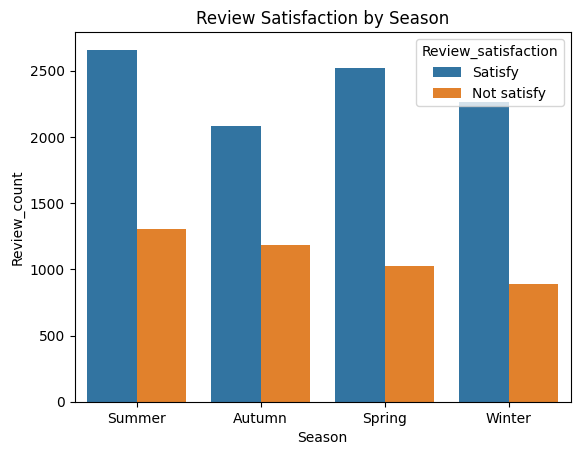

In [70]:
sns.countplot(x='Seasons', hue='Review_satisfaction', data=df_satisfaction)
plt.title('Review Satisfaction by Season')
plt.xlabel('Season')
plt.ylabel('Review_count')
plt.show()

In [71]:
# Count the number of reviews (Satisfy / Not satisfy) by nationality and by season
Reviewer_Nationality = df_satisfaction.groupby(['Reviewer_Nationality','Seasons'])['Review_satisfaction'].value_counts()

# Show result
Reviewer_Nationality

Reviewer_Nationality                   Seasons  Review_satisfaction
                                       Autumn   Not satisfy               3
                                                Satisfy                   3
                                       Spring   Not satisfy               1
                                       Summer   Satisfy                   3
                                                Not satisfy               1
                                       Winter   Satisfy                   3
Abkhazia Georgia                       Spring   Satisfy                   1
                                       Winter   Satisfy                   1
Albania                                Autumn   Satisfy                   2
                                       Spring   Not satisfy               2
                                       Summer   Satisfy                   3
                                                Not satisfy               1
                                       Winter   Satisfy                   3
Algeria                                Spring   Satisfy                   1
                                       Summer   Not satisfy               2
                                       Winter   Not satisfy               2
Andorra                                Winter   Not satisfy               1
                                                Satisfy                   1
Angola                                 Winter   Not satisfy               1
Argentina                              Autumn   Not satisfy               2
                                                Satisfy                   2
                                       Spring   Not satisfy               2
                                                Satisfy                   1
                                       Summer   Satisfy                   4
                                                Not satisfy               3
                                       Winter   Satisfy                   2
                                                Not satisfy               1
Armenia                                Autumn   Not satisfy               1
                                       Summer   Satisfy                   1
Aruba                                  Autumn   Satisfy                   1
Australia                              Autumn   Satisfy                 106
                                                Not satisfy              24
                                       Spring   Satisfy                  95
                                                Not satisfy              30
                                       Summer   Satisfy                 201
                                                Not satisfy              58
                                       Winter   Satisfy                  48
                                                Not satisfy              13
Austria                                Autumn   Not satisfy              12
                                                Satisfy                   7
                                       Spring   Not satisfy               8
                                                Satisfy                   6
                                       Summer   Satisfy                  12
                                                Not satisfy               2
                                       Winter   Satisfy                   7
                                                Not satisfy               3
Azerbaijan                             Autumn   Not satisfy               1
                                       Spring   Not satisfy               1
                                                Satisfy                   1
                                       Summer   Not satisfy               2
                                                Satisfy                   1
                                       Winter   Not sati

In [72]:
# Create a cross-tab: nationality and season as rows, satisfaction as columns
pd.crosstab([df_satisfaction['Reviewer_Nationality'], df_satisfaction['Seasons']],
            df_satisfaction['Review_satisfaction'])

Review_satisfaction                            Not satisfy  Satisfy
Reviewer_Nationality                  Seasons                      
                                      Autumn             3        3
                                      Spring             1        0
                                      Summer             1        3
                                      Winter             0        3
Abkhazia Georgia                      Spring             0        1
                                      Winter             0        1
Albania                               Autumn             0        2
                                      Spring             2        0
                                      Summer             1        3
                                      Winter             0        3
Algeria                               Spring             0        1
                                      Summer             2        0
                                      Winter             2        0
Andorra                               Winter             1        1
Angola                                Winter             1        0
Argentina                             Autumn             2        2
                                      Spring             2        1
                                      Summer             3        4
                                      Winter             1        2
Armenia                               Autumn             1        0
                                      Summer             0        1
Aruba                                 Autumn             0        1
Australia                             Autumn            24      106
                                      Spring            30       95
                                      Summer            58      201
                                      Winter            13       48
Austria                               Autumn            12        7
                                      Spring             8        6
                                      Summer             2       12
                                      Winter             3        7
Azerbaijan                            Autumn             1        0
                                      Spring             1        1
                                      Summer             2        1
                                      Winter             1        0
Bahamas                               Spring             0        1
Bahrain                               Autumn             4        4
                                      Spring             4        3
                                      Summer            11       13
                                      Winter             0        4
Bangladesh                            Autumn             0        1
                                      Summer             1        1
Barbados                              Winter             0        1
Belarus                               Autumn             0        2
                                      Summer             1        0
                                      Winter             0        1
Belgium                               Autumn            20       24
                                      Spring            18       20
                                      Summer            15       20
                                      Winter            12       25
Bhutan                                Spring             0        1
Bosnia and Herzegovina                Autumn             1        0
                                      Spring             1        2
                                      Summer             1        1
                                      Winter             0        3
Brazil                                Autumn             6        4
                                      Spring             4       12
                                      Summer            

In [73]:
# Calculate the percentage of reviews (Satisfy / Not satisfy) by nationality and by season
df_satisfaction.groupby(['Reviewer_Nationality','Seasons'])['Review_satisfaction'].value_counts(normalize=True)

Reviewer_Nationality                   Seasons  Review_satisfaction
                                       Autumn   Not satisfy            0.500000
                                                Satisfy                0.500000
                                       Spring   Not satisfy            1.000000
                                       Summer   Satisfy                0.750000
                                                Not satisfy            0.250000
                                       Winter   Satisfy                1.000000
Abkhazia Georgia                       Spring   Satisfy                1.000000
                                       Winter   Satisfy                1.000000
Albania                                Autumn   Satisfy                1.000000
                                       Spring   Not satisfy            1.000000
                                       Summer   Satisfy                0.750000
                                                Not satisfy            0.250000
                                       Winter   Satisfy                1.000000
Algeria                                Spring   Satisfy                1.000000
                                       Summer   Not satisfy            1.000000
                                       Winter   Not satisfy            1.000000
Andorra                                Winter   Not satisfy            0.500000
                                                Satisfy                0.500000
Angola                                 Winter   Not satisfy            1.000000
Argentina                              Autumn   Not satisfy            0.500000
                                                Satisfy                0.500000
                                       Spring   Not satisfy            0.666667
                                                Satisfy                0.333333
                                       Summer   Satisfy                0.571429
                                                Not satisfy            0.428571
                                       Winter   Satisfy                0.666667
                                                Not satisfy            0.333333
Armenia                                Autumn   Not satisfy            1.000000
                                       Summer   Satisfy                1.000000
Aruba                                  Autumn   Satisfy                1.000000
Australia                              Autumn   Satisfy                0.815385
                                                Not satisfy            0.184615
                                       Spring   Satisfy                0.760000
                                                Not satisfy            0.240000
                                       Summer   Satisfy                0.776062
                                                Not satisfy            0.223938
                                       Winter   Satisfy                0.786885
                                                Not satisfy            0.213115
Austria                                Autumn   Not satisfy            0.631579
                                                Satisfy                0.368421
                                       Spring   Not satisfy            0.571429
                                                Satisfy                0.428571
                                       Summer   Satisfy                0.857143
                                                Not satisfy            0.142857
                                       Winter   Satisfy                0.700000
                                                Not satisfy            0.300000
Azerbaijan                             Autumn   Not satisfy            1.000000
                                       Spring   Not satisfy            0.500000
                                                Satisfy                0.500000
            

In [74]:
# Count the number of reviews by nationality
df_satisfaction['Reviewer_Nationality'].value_counts()

,count
Reviewer_Nationality,
United Kingdom,6730
United States of America,1009
Australia,575
Ireland,404
United Arab Emirates,300
Saudi Arabia,257
Switzerland,240
Canada,204
Germany,202


In [75]:
# Count the number of reviews (Satisfy / Not satisfy) by country and by season
Reviewer_country = df_satisfaction.groupby(['Country','Seasons'])['Review_satisfaction'].value_counts().reset_index(name='count')

# Sort results by country and by number of reviews (descending)
Reviewer_country.sort_values(by=['Country','count'], ascending=False)

,Country,Seasons,Review_satisfaction,count
46,United Kingdom,Winter,Satisfy,1215
42,United Kingdom,Spring,Satisfy,1209
44,United Kingdom,Summer,Satisfy,1204
40,United Kingdom,Autumn,Satisfy,1028
41,United Kingdom,Autumn,Not satisfy,686
45,United Kingdom,Summer,Not satisfy,655
47,United Kingdom,Winter,Not satisfy,553
43,United Kingdom,Spring,Not satisfy,542
36,Spain,Summer,Satisfy,362
34,Spain,Spring,Satisfy,341


In [76]:
# Count the number of reviews (Satisfy / Not satisfy) by trip type, country, and season
Reviewer_trip = df_satisfaction.groupby(['trip_types','Country','Seasons'])['Review_satisfaction'] \
                               .value_counts() \
                               .reset_index(name='count')

# Sort results by country, trip type, satisfaction, and number of reviews (descending)
Reviewer_trip.sort_values(by=['Country','trip_types','Review_satisfaction','count'], ascending=False)


,trip_types,Country,Seasons,Review_satisfaction,count
138,Leisure trip,United Kingdom,Summer,Satisfy,1031
140,Leisure trip,United Kingdom,Winter,Satisfy,1010
136,Leisure trip,United Kingdom,Spring,Satisfy,999
134,Leisure trip,United Kingdom,Autumn,Satisfy,829
139,Leisure trip,United Kingdom,Summer,Not satisfy,488
135,Leisure trip,United Kingdom,Autumn,Not satisfy,450
141,Leisure trip,United Kingdom,Winter,Not satisfy,392
137,Leisure trip,United Kingdom,Spring,Not satisfy,373
92,Business trip,United Kingdom,Winter,Satisfy,174
88,Business trip,United Kingdom,Spring,Satisfy,173


In [77]:
# Count the number of reviews (Satisfy / Not satisfy) by trip type and by season
Reviewer_trip2 = df_satisfaction.groupby(['trip_types','Seasons'])['Review_satisfaction'] \
                                .value_counts() \
                                .reset_index(name='count')

# Sort results by trip type and number of reviews (descending)
Reviewer_trip2.sort_values(by=['trip_types','count'], ascending=False)

,trip_types,Seasons,Review_satisfaction,count
20,Leisure trip,Summer,Satisfy,2342
18,Leisure trip,Spring,Satisfy,2127
22,Leisure trip,Winter,Satisfy,1905
16,Leisure trip,Autumn,Satisfy,1713
21,Leisure trip,Summer,Not satisfy,1022
17,Leisure trip,Autumn,Not satisfy,792
19,Leisure trip,Spring,Not satisfy,753
23,Leisure trip,Winter,Not satisfy,650
8,Business trip,Autumn,Not satisfy,345
10,Business trip,Spring,Satisfy,330


In [78]:
# Count the number of reviews (Satisfy / Not satisfy) by traveler type and by season
Reviewer_traveler_types = df_satisfaction.groupby(['traveler_types','Seasons'])['Review_satisfaction'] \
                                         .value_counts() \
                                         .reset_index(name='count')

# Sort results by traveler type and number of reviews (descending)
Reviewer_traveler_types.sort_values(by=['traveler_types','count'], ascending=False)

,traveler_types,Seasons,Review_satisfaction,count
46,Solo traveler,Winter,Satisfy,454
42,Solo traveler,Spring,Satisfy,452
44,Solo traveler,Summer,Satisfy,430
40,Solo traveler,Autumn,Satisfy,391
41,Solo traveler,Autumn,Not satisfy,377
45,Solo traveler,Summer,Not satisfy,280
43,Solo traveler,Spring,Not satisfy,275
47,Solo traveler,Winter,Not satisfy,260
34,Group,Spring,Satisfy,377
36,Group,Summer,Satisfy,330


In [79]:
df_satisfaction.head(10)

,Additional_Number_of_Scoring,Review_Date,Average_Score,Hotel_Name,Reviewer_Nationality,Negative_Review,Review_Total_Negative_Word_Counts,Total_Number_of_Reviews,Positive_Review,Review_Total_Positive_Word_Counts,Total_Number_of_Reviews_Reviewer_Has_Given,Reviewer_Score,Country,City,Address,cleaned_tags,room_type,layout,room_count,capacity,features,pet_info,reservation_method,traveler_types,trip_types,stay_duration,Seasons,Review_satisfaction
0,904,2017-07-21,8.1,Hotel Da Vinci,United Kingdom,Would have appreciated a shop in the hotel th...,52,16670,Hotel was great clean friendly staff free bre...,62,1,9.6,Italy,Milan,Via Senigallia 6 20161,Double Room,Double Room,Standard,,,,No pets,Reserved from PC or tablet,Couple,Leisure trip,Stayed 2 nights,Summer,Satisfy
3,241,2015-10-17,9.1,Hotel Principe Di Savoia,United States of America,No Negative,0,1543,Everything including the nice upgrade The Hot...,27,9,10.0,Italy,Milan,Piazza Della Repubblica 17 Central Station 20124,Ambassador Junior Suite,Suite,Standard,,,,No pets,Reserved from PC or tablet,Couple,Leisure trip,Stayed 1 night,Autumn,Satisfy
4,834,2016-05-16,9.1,Hotel Esther a,United Kingdom,No Negative,0,4687,Lovely hotel v welcoming staff,7,2,9.6,Netherlands,Amsterdam,Singel 303 309 Amsterdam City Center 1012 WJ,Classic Double or Twin Room,Double Room,Standard,,,,No pets,Reserved from mobile device,Solo traveler,Business trip,Stayed 2 nights,Spring,Satisfy
8,211,2016-06-25,8.9,Hotel Saint Petersbourg Opera,Ireland,Pity about the two days of rain,8,2412,Its centrality proximity to our destination,7,1,9.2,France,Paris,35 Rue Caumartin 9th arr 75009,Double or Twin Room,Double Room,Standard,,,,No pets,Reserved from PC or tablet,Group,,Stayed 1 night,Summer,Satisfy
9,61,2015-09-30,7.4,St George Hotel,Canada,Didn t like it at all construction was in pro...,18,334,Didn t like anything about the stay if i had ...,25,1,2.5,United Kingdom,London,49 Gloucester Place Marble Arch Westminster Bo...,Standard Triple Room,Other,Standard,,,,No pets,Reserved from mobile device,Couple,,Stayed 2 nights,Autumn,Not satisfy
10,127,2016-01-22,8.1,Barcel Milan,United Kingdom,N A,3,3228,Free upgrade in Executive Double room complem...,44,3,10.0,Italy,Milan,Via Giorgio Stephenson 55 20157,Superior Double Room,Double Room,Standard,,,,No pets,Reserved from PC or tablet,Couple,Leisure trip,Stayed 1 night,Winter,Satisfy
13,312,2017-04-26,8.5,Ayre Hotel Caspe,Italy,In the room they gave us first wi fi signal w...,56,3442,The staff was very kind and polite and they q...,28,10,9.6,Spain,Barcelona,Caspe 103 Eixample 08013,Double or Twin Room,Double Room,Standard,,,,No pets,Reserved from PC or tablet,Couple,Leisure trip,Stayed 3 nights,Spring,Satisfy
14,170,2016-10-10,8.5,Best Western Atlantic Hotel,Australia,Breakfast was okay Typical European but did s...,22,1738,Handy location can see it from the Central tr...,26,14,9.2,Italy,Milan,Via Napo Torriani 24 Central Station 20124,Junior Suite,Suite,Standard,,,,No pets,Reserved from PC or tablet,Couple,Leisure trip,Stayed 2 nights,Autumn,Satisfy
15,125,2016-09-22,9.3,Luxury Suites Amsterdam,Seychelles,No Negative,0,720,I loved everything about the place The locati...,34,1,9.6,Netherlands,Amsterdam,Oudeschans 75 Amsterdam City Center 1011 KW,Royal Suite with Canal View,Suite,Standard,,,View,No pets,Reserved from mobile device,Couple,,Stayed 7 nights,Autumn,Satisfy
16,838,2016-01-21,8.4,The Grosvenor,United Kingdom,1 Bed was faulty seemed to dip in the middle ...,57,3274,Locate ideal clean facility,5,6,4.6,United Kingdom,London,101 Buckingham Palace Road Westminster Borough,Standard Single Room,Single Room,Standard,,,,No pets,Reserved from PC or tablet,Solo traveler,Business trip,Stayed 1 night,Winter,Not satisfy


# **AXIS 3 - Does the number of reviews posted by a user influence their severity?**

In [80]:
# Filtering active users (more than 50 reviews given)
df_user_actif = df_satisfaction[df_satisfaction['Total_Number_of_Reviews_Reviewer_Has_Given'] > 50]
df_user_actif.to_csv('df_user_actif.csv',index=False)

In [81]:
df_user_actif.shape

(104, 28)

In [82]:
# Distribution of reviews (Satisfy / Not satisfy) among active users
df_user_actif['Review_satisfaction'].value_counts()

,count
Review_satisfaction,
Satisfy,72
Not satisfy,32


In [83]:
# Filtering less active users (fewer than 11 reviews given)
df_user_not_actif = df_satisfaction[df_satisfaction['Total_Number_of_Reviews_Reviewer_Has_Given'] < 11]
df_user_not_actif.to_csv('df_user_not_actif.csv',index=False)

In [84]:
df_user_not_actif.shape

(11406, 28)

In [85]:
# Distribution of reviews (Satisfy / Not satisfy) among less active users
df_user_not_actif['Review_satisfaction'].value_counts()

,count
Review_satisfaction,
Satisfy,7809
Not satisfy,3597


Review_satisfaction        Satisfy  Not satisfy  % Satisfy  % Not satisfy
Reviewer_Nationality                                                     
Germany                          1            2      33.33          66.67
Israel                           2            2      50.00          50.00
Russia                           2            2      50.00          50.00
Switzerland                      6            4      60.00          40.00
Romania                          2            1      66.67          33.33
Belgium                          3            1      75.00          25.00
United States of America         3            1      75.00          25.00
United Kingdom                  14            3      82.35          17.65
Australia                        6            0     100.00           0.00
Italy                            4            0     100.00           0.00


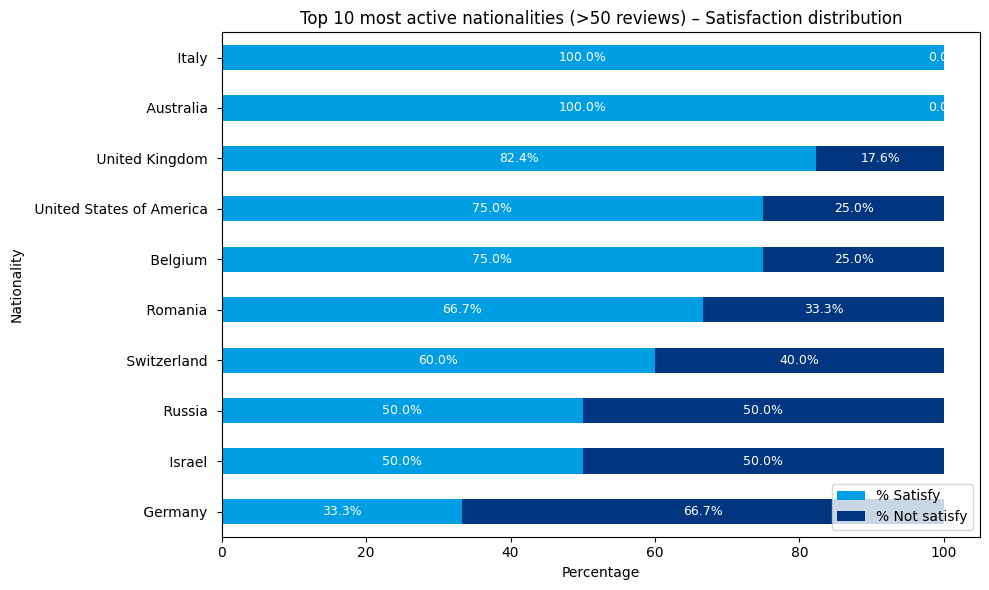

In [86]:
# Selecting the 10 most represented nationalities among very active users
top_nationalites = df_user_actif['Reviewer_Nationality'].value_counts().head(10).index.tolist()

# Filtering to keep only these nationalities
df_top = df_user_actif[df_user_actif['Reviewer_Nationality'].isin(top_nationalites)]

# Distribution of Satisfy / Not satisfy by nationality
repartition_top = df_top.groupby(['Reviewer_Nationality', 'Review_satisfaction']).size().unstack(fill_value=0)

# Calculate percentages
repartition_top['Total'] = repartition_top.sum(axis=1)
repartition_top['% Satisfy'] = (repartition_top['Satisfy'] / repartition_top['Total']) * 100
repartition_top['% Not satisfy'] = 100 - repartition_top['% Satisfy']

# Sort nationalities by percentage of dissatisfaction
repartition_top = repartition_top.sort_values(by='% Not satisfy', ascending=False)

# Display rounded results
print(repartition_top[['Satisfy', 'Not satisfy', '% Satisfy', '% Not satisfy']].round(2))

# Stacked horizontal chart
repartition_top[['% Satisfy', '% Not satisfy']].plot(
    kind='barh',
    stacked=True,
    figsize=(10, 6),
    color=['#009FE3', '#003580']
)

# Add annotations on the bars
for index, (satisfy, not_satisfy) in enumerate(zip(repartition_top['% Satisfy'], repartition_top['% Not satisfy'])):
    plt.text(satisfy / 2, index, f"{satisfy:.1f}%", va='center', ha='center', color='white', fontsize=9)
    plt.text(satisfy + not_satisfy / 2, index, f"{not_satisfy:.1f}%", va='center', ha='center', color='white', fontsize=9)

# Formatting the chart
plt.title("Top 10 most active nationalities (>50 reviews) – Satisfaction distribution")
plt.xlabel("Percentage")
plt.ylabel("Nationality")
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()




